In [1]:
#load package

library(dplyr)
library(Biostrings)
library(ggplot2)
library(dplyr)
library(data.table)
library(rtracklayer)
library(dplyr)
library(ggbio)
library(reshape2)
library(ggsci)
library(viridis)
library(ggpubr)
library(ggh4x)
library(khroma)
library(qs)
MySplit = function(str,sep, n){
  return(unlist(lapply(strsplit(str,sep),"[[",n)))
}


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘Biostrings’ was built under R version 4.3.3”
Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading re

In [2]:
anotdf = read.csv("all_ani_total_25_08_20.csv")
tax_df = read.csv("refdata/taxon_class_08_21.csv")
anotdf = merge(anotdf,tax_df,by = "species")

## Figure4a

In [22]:
library(Biostrings)
library(circlize)
reffa <- readDNAStringSet("pBI143_ref/Genbankref.fasta")
seq_names <- names(reffa)
seq_lengths <- width(reffa)

covdf = read.delim("pBI143_ref/coverage_per_base.txt",header = F)

colnames(covdf) = c("chr","start","coverage")
covdf$end = covdf$start
covdf$coverage = covdf$coverage/max(covdf$coverage)
covdf = covdf[,c("chr","start","end","coverage")]



track = data.frame(
    name  = c("U30316.1"),
    start = c(1),
    end   = c(2747))
circos.genomicInitialize(track,major.by = 500,axis.labels.cex = 1)

# circos.track(ylim = c(0, 0.5), 
#     bg.col = c("#FF000040"), 
#     bg.border = NA, track.height = 0.05)
sectors = "U30316.1"
circos.trackPlotRegion(sectors, ylim = c(0, 1), track.height = 0.1)
circos.lines(covdf$start, covdf$coverage, sector.index = sectors,type = "l", 
             area = TRUE,col = c("#bde0fe"))
#circos.text(2100,-1,"Total coverage of pBI143", sector.index = sectors)

sectors2 = "U30316.1"
circos.trackPlotRegion(sectors2, ylim = c(0, 1), track.height = 0.2,bg.border = NA)
gene_ano = data.frame(phase = factor(c("mobA", "repA")),
                        x1 = c(24, 1468),
                      x2 = c(1127, 2148))
circos.arrow(gene_ano$x1[1], gene_ano$x2[1], 
        arrow.head.width = 0.8, arrow.head.length = cm_x(0.5),
        col = "#EFCD60",sector.index = sectors2)
circos.text((gene_ano$x2[1]-gene_ano$x1[1])/2 + gene_ano$x1[1], 0.5,labels = "mobA", 
            sector.index = sectors2, facing = "downward")
circos.arrow(gene_ano$x1[2], gene_ano$x2[2], 
        arrow.head.width = 0.8, arrow.head.length = cm_x(0.5),
        col = "#2B5194",sector.index = sectors2)
circos.text((gene_ano$x2[2]-gene_ano$x1[2])/2 + gene_ano$x1[2], 0.5,labels = "repA", 
            sector.index = sectors2, facing = "downward")

text(0, 0, "U30316.1\npBI143 2747bp", cex = 2)

[1] "U30316.1 Bacteroides fragilis strain IB143 plasmid pBI143, complete sequence"

[1] 2747

In [ ]:
# Create test data.
library(RColorBrewer)
data <- data.frame(
  category=c("With pBI143", "No pBI143"),
  count=c(17406, 57395 - 17406)
)
myPalette <- brewer.pal(3, "Set2") 

data$prop = data$count/sum(data$count)
data$category = paste0(data$category,"(",round(data$prop*100,1),"%)")
pdf("../downstream_analysis/figures/pBI143_ratio_pie_plot_25_07_05.pdf",width = 4,height = 4)
pie(data$count , labels = data$category,col = myPalette)
dev.off()

## Figure4b-f

file saved to ../downstream_analysis/figures/pBI143_cell_ratio_sample_stat_25_09_14.pdf



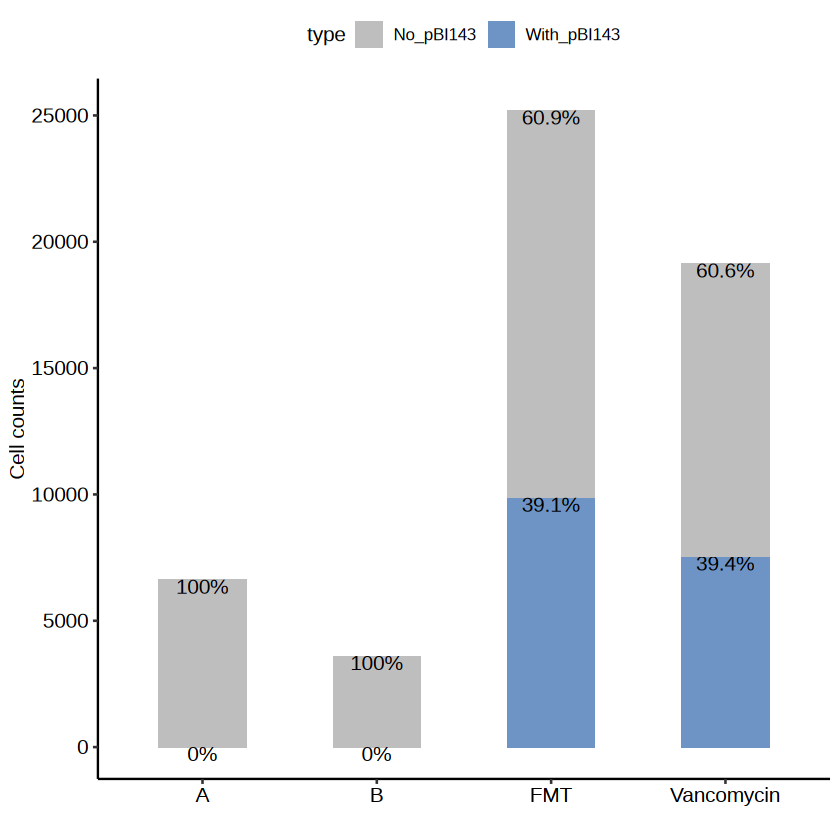

In [83]:
p1.0 = ggplot(pbidf.st,aes(x = group,y = celln,fill = type)) + 
    geom_bar(stat = "identity",position = "stack",width = 0.5) + 
    geom_text(aes(y = celln,label = label),position = "stack",vjust = 1) + 
    theme_pubr() + 
    scale_fill_manual(values = c("grey","#6D94C5")) + ylab("Cell counts") + xlab("")
p1.0
ggexport(p1.0,filename = "../downstream_analysis/figures/pBI143_cell_ratio_sample_stat_25_09_14.pdf",width = 3,height = 4)

In [224]:
##load data
pbidf = read.delim("up10_all_pBI143_copy_number.txt",header = T)
pbidf$sample = pbidf$group
length(unique(pbidf$new_name))
length(unique(pbidf$new_name))
#length(unique(celldivdf$new_name))
pbidf$group = MySplit(pbidf$sample,"_",1)
pbidf$condition = MySplit(pbidf$sample,"_",2)
pbidf[pbidf$group == "C282",]$group = "Vancomycin"
pbidf[pbidf$group == "C295",]$group = "FMT"

[1] 17406

[1] 17406

In [ ]:
colordf = read.csv(file = "refdata/color_assign_new.csv")
color_vector = colordf$color_vector
names(color_vector) = colordf$X
pbidf.st.spc = pbidf %>% group_by(species) %>% dplyr::summarise(celln = length(unique(new_name)))
cell.st.spc = anotdf %>% group_by(species,order,class) %>% dplyr::summarise(cellnt = length(unique(name)))
pbidf.st.spc = merge(pbidf.st.spc,cell.st.spc,by = c("species"))
pbidf.st.spc$prop = pbidf.st.spc$celln/pbidf.st.spc$cellnt
pbidf.st.spc = pbidf.st.spc[order(-pbidf.st.spc$prop),]
pbidf.st.spc = pbidf.st.spc[pbidf.st.spc$cellnt > 10,]
pbidf.st.spc$species = factor(pbidf.st.spc$species,levels = unique(pbidf.st.spc$species))
p2.0 = ggplot(pbidf.st.spc,aes(x = species,y = prop,fill = class)) + 
    geom_bar(stat = "identity",width = 0.7) +
    #scale_fill_manual(values = color_vector) +
    scale_fill_brewer(palette = "Paired") +
    theme_pubr() +
    xlab("") + ylab("Ratio of cells with pBI143 of different species") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p2.0


In [228]:
#length(unique(pbidf.st.spc$species))
pbidf.st = pbidf %>% group_by(species) %>% summarise(plas_ratio = mean(plas_ratio))
pbidf.st = pbidf.st[pbidf.st$plas_ratio > 0,]
pbidf.st[pbidf.st$species %in% c("Lancefieldella sp000564995","Anaerococcus murdochii"),]

species,plas_ratio
<chr>,<dbl>
Anaerococcus murdochii,0.02828453
Lancefieldella sp000564995,0.02608774


[1] 73

species,plas_ratio
<fct>,<dbl>
Phocaeicola vulgatus,11.522227
Holdemania massiliensis,6.137956
Bacteroides xylanisolvens,5.648819
Bacteroides ovatus,4.671653
Parabacteroides goldsteinii,3.022470
Parabacteroides distasonis,2.983875


file saved to ../downstream_analysis/figures/f2.0_pBI143_reads_ratio_species_25_09_17.pdf



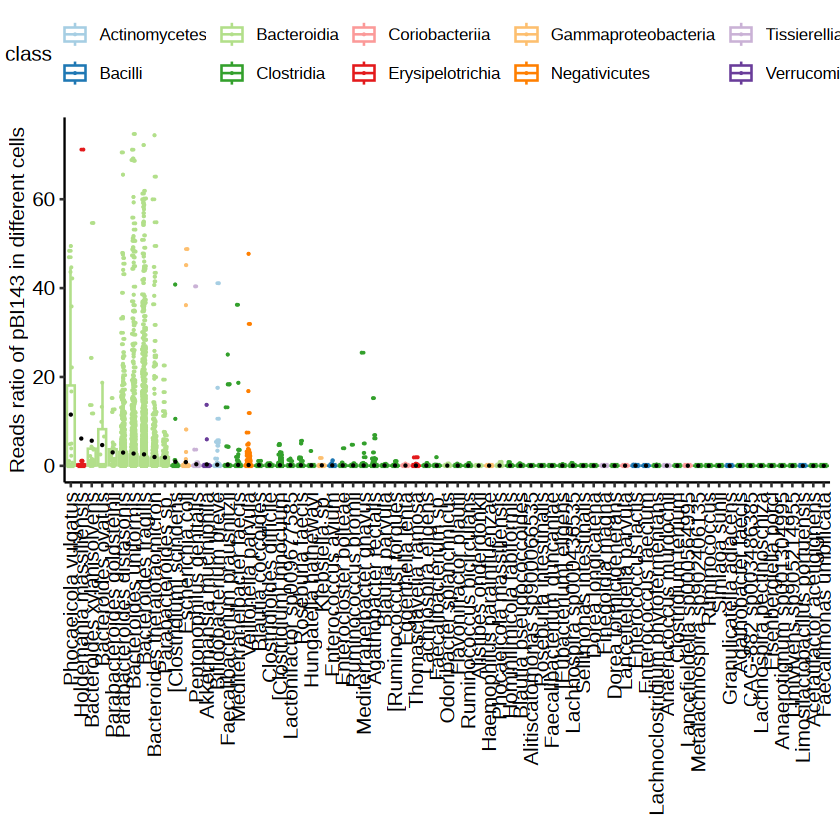

In [572]:
# pbidf = merge(pbidf,tax_df,by = "species")
pbidf.st = pbidf %>% group_by(species) %>% summarise(plas_ratio = mean(plas_ratio))
pbidf.st = pbidf.st[pbidf.st$plas_ratio > 0,]
nrow(pbidf.st)
pbidf.st = pbidf.st[order(-pbidf.st$plas_ratio),]
head(pbidf.st)
pbidf$species = factor(pbidf$species,levels = pbidf.st$species)
p1.0 = ggplot(pbidf,aes(x = species,y = plas_ratio,color = class)) + 
    geom_boxplot(outlier.size = 0) + geom_jitter(size = 0.01,width = 0.2) +
    geom_point(data = pbidf.st, aes(x = species, y = plas_ratio), 
              size = 0.1, color = "black") +
    #scale_fill_manual(values = color_vector) +
    scale_fill_brewer(palette = "Paired") +
    scale_color_brewer(palette = "Paired") +
    theme_pubr() +
    xlab("") + ylab("Reads ratio of pBI143 in different cells") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p1.0


In [5]:
pbidf[pbidf$condition == "1",]$condition = "Pretreatment"
pbidf[pbidf$condition == "2",]$condition = "Ontreatment"
pbidf[pbidf$condition == "3",]$condition = "Posttreatment"
unique(pbidf$condition)

[1] "Pretreatment"  "Ontreatment"   "Posttreatment"

In [6]:
anotdf.st = anotdf %>% group_by(group) %>% summarise(cellnt = length(unique(name)))
pbidf.st = pbidf %>% group_by(group) %>% summarise(celln = length(unique(new_name)))
pbidf.st = merge(pbidf.st,anotdf.st,by = "group",all = TRUE)
pbidf.st[is.na(pbidf.st$celln),]$celln = 0
pbidf.st$type = "With_pBI143"
pbidf.st2 = pbidf.st
pbidf.st2$celln = pbidf.st2$cellnt - pbidf.st2$celln
pbidf.st2$type = "No_pBI143"
pbidf.st = rbind(pbidf.st,pbidf.st2)
pbidf.st$cellp = pbidf.st$celln/pbidf.st$cellnt
pbidf.st$label = paste0(round(pbidf.st$cellp*100,1),"%")
pbidf.st

group,celln,cellnt,type,cellp,label
<chr>,<dbl>,<int>,<chr>,<dbl>,<chr>
A,0,6619,With_pBI143,0.0000000,0%
B,0,3604,With_pBI143,0.0000000,0%
FMT,9864,25197,With_pBI143,0.3914752,39.1%
Vancomycin,7542,19144,With_pBI143,0.3939616,39.4%
A,6619,6619,No_pBI143,1.0000000,100%
B,3604,3604,No_pBI143,1.0000000,100%
FMT,15333,25197,No_pBI143,0.6085248,60.9%
Vancomycin,11602,19144,No_pBI143,0.6060384,60.6%


In [7]:
#select hub pBI143
pbidf.hub = pbidf %>% group_by(group,species) %>% summarise(mcp = mean(copy_number))
pbidf.hub = pbidf.hub[pbidf.hub$mcp > 20,]
pbidf.hub

`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.


group,species,mcp
<chr>,<chr>,<dbl>
FMT,Bacteroides fragilis,61.88233
FMT,Bacteroides ovatus,216.69918
FMT,Bacteroides thetaiotaomicron,2885.20526
FMT,Bacteroides uniformis,140.93897
FMT,Bacteroides xylanisolvens,297.14567
FMT,Escherichia coli,409.64905
FMT,Holdemania massiliensis,807.62910
FMT,Parabacteroides distasonis,132.59055
FMT,Parabacteroides goldsteinii,266.35792


`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.
file saved to ../downstream_analysis/figures/pBI143_hubspecies_sample_compare_25_09_26.pdf



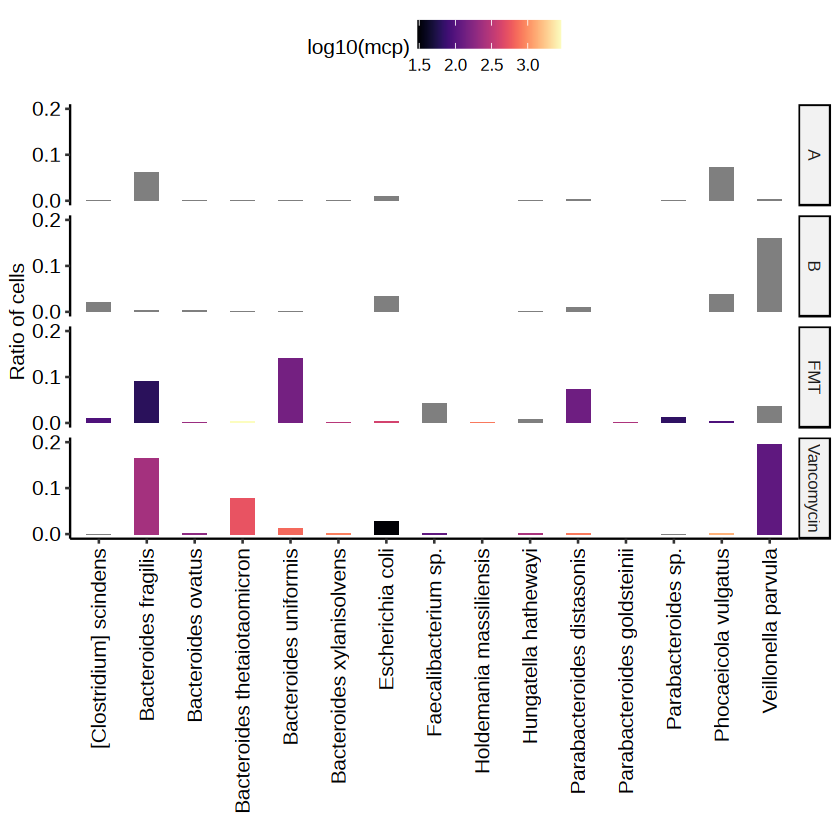

In [8]:
#pbidf.st.spc = pbidf %>% group_by(group,condition,species) %>% dplyr::summarise(celln = length(unique(new_name)))
cell.st.spc = anotdf %>% group_by(group) %>% mutate(cellnt = length(unique(name))) %>%
            group_by(group,species) %>% 
            dplyr::summarise(celln = length(unique(name)),cellp = celln/cellnt[1])
#pbidf.st.spc = merge(pbidf.st.spc,cell.st.spc,by = c("group","condition","species"))
#pbidf.st.spc$prop = pbidf.st.spc$celln/pbidf.st.spc$cellnt
cell.st.spc = cell.st.spc[cell.st.spc$species %in% pbidf.hub$species,]
cell.st.spc = merge(cell.st.spc,pbidf.hub,by = c("group","species"),all = TRUE)
cell.st.spc[is.na(cell.st.spc$mcp),]$mcp = 0
#pbidf.st.spc = pbidf.st.spc[order(-pbidf.st.spc$p""rop),]
# pbidf.st.spc = pbidf.st.spc[pbidf.st.spc$cellnt > 10,]
# pbidf.st.spc = pbidf.st.spc[pbidf.st.spc$prop > 0.1,]
p0.1 = ggplot(cell.st.spc,aes(x = species, y = cellp,fill = log10(mcp))) +
    geom_bar(stat = "identity",position = "dodge",width = 0.5) +  
    scale_fill_viridis(option = "A") +
    facet_grid(group~.) +    
    theme_pubr() + 
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5)) + 
    ylab("Relitave abundance") + xlab("") + scale_y_continuous(breaks = c(0,0.1,0.2),limits = c(0,0.2))
p0.1
ggexport(p0.1,filename = "../downstream_analysis/figures/pBI143_hubspecies_sample_compare_25_09_26.pdf",width = 5,height = 7)

In [77]:
#selcet different version cells
pbidfv = read.delim("pBI143_sourmash_group_anno.txt",header = T)
#pbidf = merge(pbidf,pbidfv[,c("new_name","pBI143_version")],by = "new_name")
pbidf.case = pbidf %>% group_by(pBI143_version) %>% top_n(wt = copy_number,n = 1)
pbidf.case
# head(pbidf)
# pbidf %>% group_by()

new_name,name.x,plas_reads_num,species,GCA,ANI,db,fastq_num,plas_ratio,name.y,pBI143_depth,genome_depth,group,copy_number,log,sample,condition,pBI143_version
<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<chr>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<int>
C282_1_lib2_out_AAGGTTCACAGAGACATAGTCAGCATGAT,lib2_out_AAGGTTCACAGAGACATAGTCAGCATGAT,10143,Bacteroides thetaiotaomicron,GCF_024758905.1,99.82,refseq,20502,49.473222,lib2_out_AAGGTTCACAGAGACATAGTCAGCATGAT,3571.68475,0.009298774,Vancomycin,384102.7678,12.858665,C282_1,1,4
C282_1_lib2_out_GACCTGGACAGTGAGCCGGTCAGACCTGG,lib2_out_GACCTGGACAGTGAGCCGGTCAGACCTGG,487,Bacteroides fragilis,GCF_000965785.1,100.00,refseq,1276,38.166144,lib2_out_GACCTGGACAGTGAGCCGGTCAGACCTGG,93.57444,0.013348335,Vancomycin,7010.1962,8.855121,C282_1,1,1
C282_2_lib1_out_TGAGCCGACAGGCCTCTAGTCAAGTGGGA,lib1_out_TGAGCCGACAGGCCTCTAGTCAAGTGGGA,297,Bacteroides fragilis,GCF_000724795.2,100.00,refseq,1136,26.144366,lib1_out_TGAGCCGACAGGCCTCTAGTCAAGTGGGA,37.14962,0.028355128,Vancomycin,1310.1552,7.177901,C282_2,2,3
C295_1_lib1_out_AGAGCTTACAGACTTTCAGTCAGTGCTTC,lib1_out_AGAGCTTACAGACTTTCAGTCAGTGCTTC,263,Parabacteroides distasonis,GCF_024758245.1,99.65,refseq,1389,18.934485,lib1_out_AGAGCTTACAGACTTTCAGTCAGTGCTTC,56.70040,0.054804486,FMT,1034.5942,6.941765,C295_1,1,5
C295_1_lib1_out_GACGTTAACAGACGCAGAGTCAGGGCTAA,lib1_out_GACGTTAACAGACGCAGAGTCAGGGCTAA,69,Bacteroides uniformis,GCF_018291785.1,99.30,refseq,1969,3.504317,lib1_out_GACGTTAACAGACGCAGAGTCAGGGCTAA,16.68365,0.137529386,FMT,121.3097,4.798347,C295_1,1,6
C295_1_lib2_out_GGCAATTACAGTTGGAACGTCAGTATCTT,lib2_out_GGCAATTACAGTTGGAACGTCAGTATCTT,170,Bacteroides uniformis,GCF_018291785.1,100.00,refseq,1396,12.177650,lib2_out_GGCAATTACAGTTGGAACGTCAGTATCTT,43.63014,0.002347869,FMT,18582.8690,9.829995,C295_1,1,2


In [66]:
#ggdensity(pbidf$pBI143_depth/pbidf$plas_reads_num)
p1.0 = gghistogram(log10(pbidf$copy_number),bins = 50) + xlab("Copy number of pBI143 in single cell")
ggexport(p1.0, 
         filename = "../downstream_analysis/figures/f2.0_pBI143_copynumber_density_25_07_05.pdf",
         width = 4,height = 4)

file saved to ../downstream_analysis/figures/f2.0_pBI143_copynumber_density_25_07_05.pdf



## Figure4g-i

In [13]:
pbidf.hub = pbidf[pbidf$plas_reads_num > 100,]
nrow(pbidf.hub)

[1] 2010

In [18]:
#select complete fasta
pbiref = read.delim("pBI143_ref/refmap/all_pairs_thred0_total_ref.ani")
#pbiref = pbiref[pbiref$Ref_name == "U30316.1",]
pbiref$name = substr(pbiref$Query_file,104,nchar(pbiref$Query_file)-6)
sampledf = unique(anotdf[,c("name","sample","species","condition","group")])
pbiref = pbiref[order(pbiref$name),]
pbiref = merge(pbiref,sampledf,by = "name")
nrow(pbiref)
#pbiref.fil = pbiref[pbiref$Align_fraction_ref > 80,]
#nrow(pbiref.fil)
pbiref.fil = pbiref[pbiref$name %in% pbidf.hub$new_name,]
length(unique(pbiref.fil$Query_file))

[1] 36764

[1] 2010

In [197]:
#try to construct pBI143 version from contig tree
fasta_file = "/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/pBI143_all_seq.fasta"
pbiseq <- readDNAStringSet(fasta_file)

Warning message in .Call2("fasta_index", filexp_list, nrec, skip, seek.first.rec, :
"reading FASTA file /cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/pBI143_all_seq.fasta: ignored 9 invalid one-letter sequence codes"


In [19]:

fasta_files = unique(pbiref.fil$Query_file)
seq_list <- list()
name_vector <- character(length(fasta_files))

for (i in seq_along(fasta_files)) {
  file_path <- fasta_files[i]
  seq <- readDNAStringSet(file_path)[[1]] 
  seq_name <- tools::file_path_sans_ext(basename(file_path))

  seq_list[[i]] <- seq
  name_vector[i] <- seq_name
}

combined_sequences <- DNAStringSet(unlist(seq_list))
names(combined_sequences) <- name_vector
writeXStringSet(combined_sequences, filepath = output_file)


Warning message in fortify(data, ...):
"Arguments in `...` must be used.
✖ Problematic arguments:
• as.Date = as.Date
• yscale_mapping = yscale_mapping
• hang = hang
• size = 0.3
ℹ Did you misspell an argument name?"


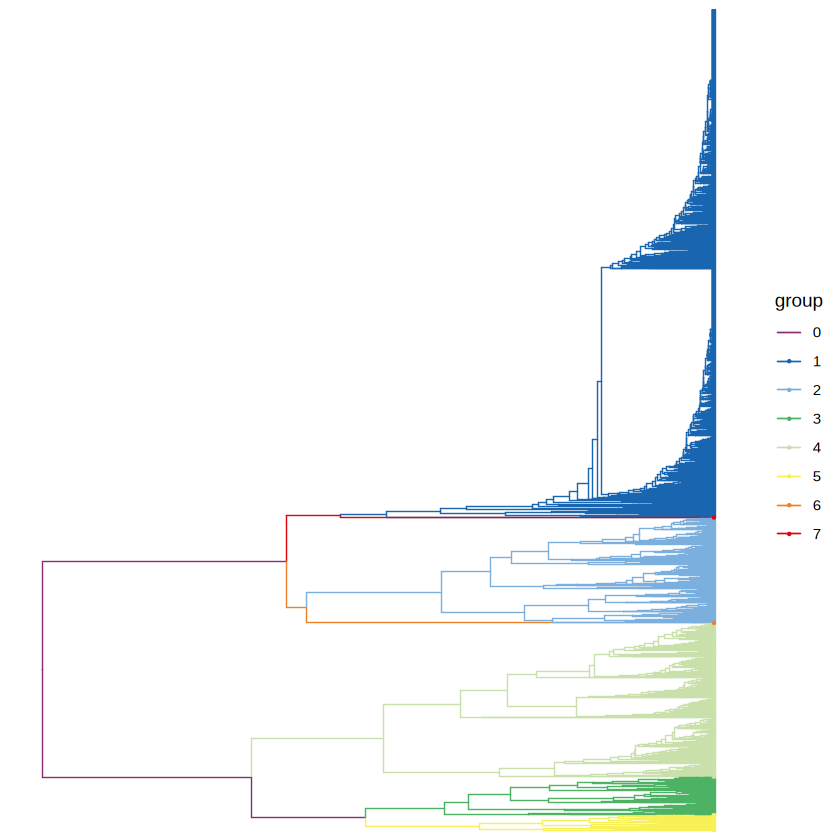

In [31]:
library(Biostrings)
library(msa)
library(ape)
library(phangorn)
library(dplyr)
library(ggtree)
aligned_sequences <- readDNAMultipleAlignment("pBI143_ref/cell_tree/pBI143_all_seq_aligned_25_10_07.fasta")
aligned_dnabin <- as.DNAbin(aligned_sequences)
dist_mat <- dist.dna(aligned_dnabin, model = "K80", pairwise.deletion = TRUE)
hc <- hclust(as.dist(dist_mat), method = "complete")

Warning message in fortify(data, ...):
"Arguments in `...` must be used.
✖ Problematic arguments:
• as.Date = as.Date
• yscale_mapping = yscale_mapping
• hang = hang
• size = 0.3
ℹ Did you misspell an argument name?"


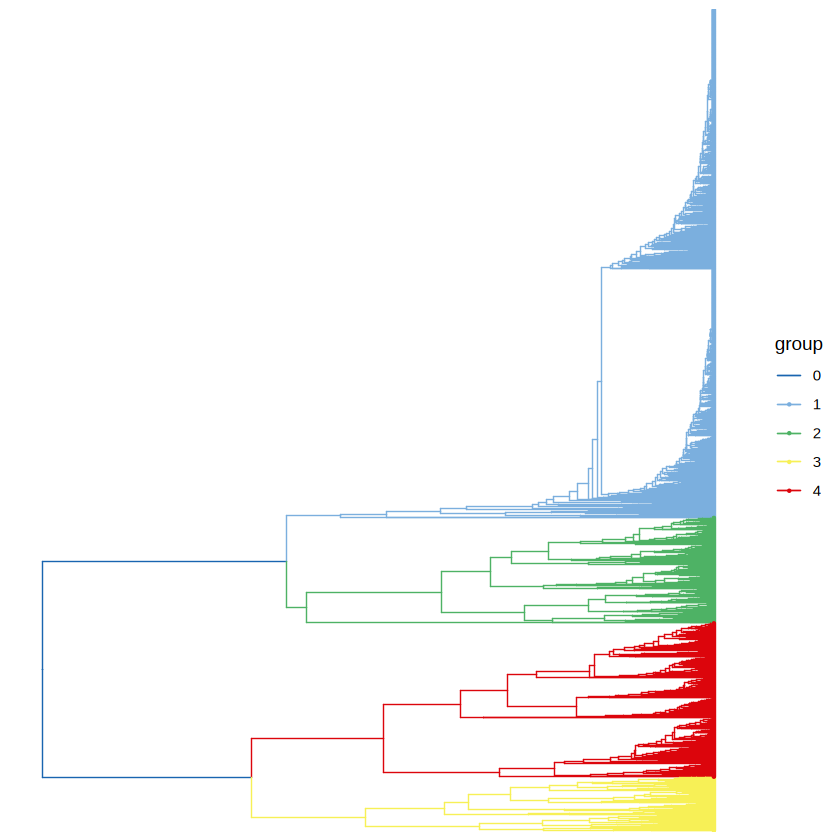

In [34]:
clusters <- cutree(hc, k = 4) 
# nj_tree <- nj(dist_mat)
group_list <- split(names(clusters), clusters)
#dend <- as.dendrogram(hc)
phylo_tree <- as.phylo(hc)
#head(group_list)
tree_grouped <- groupOTU(phylo_tree, group_list, group_name = "group")
options(ignore.negative.edge=TRUE)
ptr <- ggtree(tree_grouped, aes(color = group),size = 0.3) + 
  geom_tippoint(aes(color = group), size=0.2) + scale_color_discreterainbow()
ptr

In [52]:
## plot case
# 1. 加载必要的包
library(Biostrings)
library(msa)
library(seqinr)
#pBI143 diversity and tree plot
pbidfv = read.delim("pBI143_sourmash_group_anno.txt",header = T)
dna_string_set <- as(aligned_sequences, "DNAStringSet")
seq_names <- names(dna_string_set)
head(seq_names)
unique_groups <- unique(clusters)

consensus_seqs_list <- lapply(unique_groups, function(grp) {

    seqs_in_this_group <- names(clusters[clusters == grp])
    group_dna_ss <- dna_string_set[seqs_in_this_group]

    cons_string <- consensusString(group_dna_ss, 
                                   threshold = 0.5, 
                                   ambiguity = "N")

    return(cons_string)
})

names(consensus_seqs_list) <- unique_groups
fasta_file <- "pBI143_ref/cell_tree/version_consensus_sequences_25_10_07.fasta"
sink(fasta_file)
for (group_name in names(consensus_seqs_list)) {
    cat(paste0(">Version", group_name, "\n"))
    cat(gsub(consensus_seqs_list[[group_name]],pattern = "-",replacement = ""), "\n")
}
sink()
# fasta_dir <- "/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/msa/"
# fasta_files <- list.files(path = fasta_dir, pattern = "\\.fasta$|\\.fa$|\\.fas$", full.names = TRUE)
# all_sequences <- DNAStringSet()
# for (file in fasta_files) {
#   sequences <- readDNAStringSet(file)
#   all_sequences <- c(all_sequences, sequences)
# }
all_sequences = readDNAStringSet("pBI143_ref/cell_tree/version_consensus_sequences_withan.fasta")
my_alignment <- msa(all_sequences, method = "ClustalW") # 根据你的数据和需求选择方法
print(my_alignment)
aln_seqinr <- msaConvert(my_alignment, type = "seqinr::alignment")
seq_matrix <- as.matrix(aln_seqinr)
dim(seq_matrix)

# writeXStringSet(unmasked(my_alignment), file = "/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/msa_case/my_multiple_alignment.fasta", format = "fasta")
# write.table(seq_matrix, file = "/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/msa_case/alignment_matrix.txt", quote = FALSE, sep = "\t")

Warning message in .Call2("fasta_index", filexp_list, nrec, skip, seek.first.rec, :
"reading FASTA file pBI143_ref/cell_tree/version_consensus_sequences_withan.fasta: ignored 4 invalid one-letter sequence codes"


use default substitution matrix
CLUSTAL 2.1  

Call:
   msa(all_sequences, method = "ClustalW")

MsaDNAMultipleAlignment with 7 rows and 3069 columns
    aln                                                    names
[1] --------------------------...CAGCCGGCTGTCACCGGCTGTTATC U30316.1
[2] --------------------------...CAGCCGGCTGTCACCGGCTGTTATC Version4
[3] --------------------------...CAGCCGGCTGTCACCGGCTGTTATC Version3
[4] --------------------------...CAGCCGGCTGTCACCGGCTGTTATC Version1
[5] --------------------------...CAGCCGGCTGTCACCGGCTGTTATC Version2
[6] AAAGCCGCTGGAGATGTCGGATGTCC...------------------------- Version1_USA0006
[7] AAAGCCGCTGGGGATGTCGGATGTCC...------------------------- Version2_CHI0054
Con --------------------------...CAGCCGGCTGTCACCGGCTGTTATC Consensus 


[1]    7 3069

Warning message in fortify(data, ...):
"Arguments in `...` must be used.
✖ Problematic arguments:
• as.Date = as.Date
• yscale_mapping = yscale_mapping
• hang = hang
• size = 0.3
ℹ Did you misspell an argument name?"
file saved to ../downstream_analysis/figures/consensus_pBI143_seq_tree_25_10_06.pdf



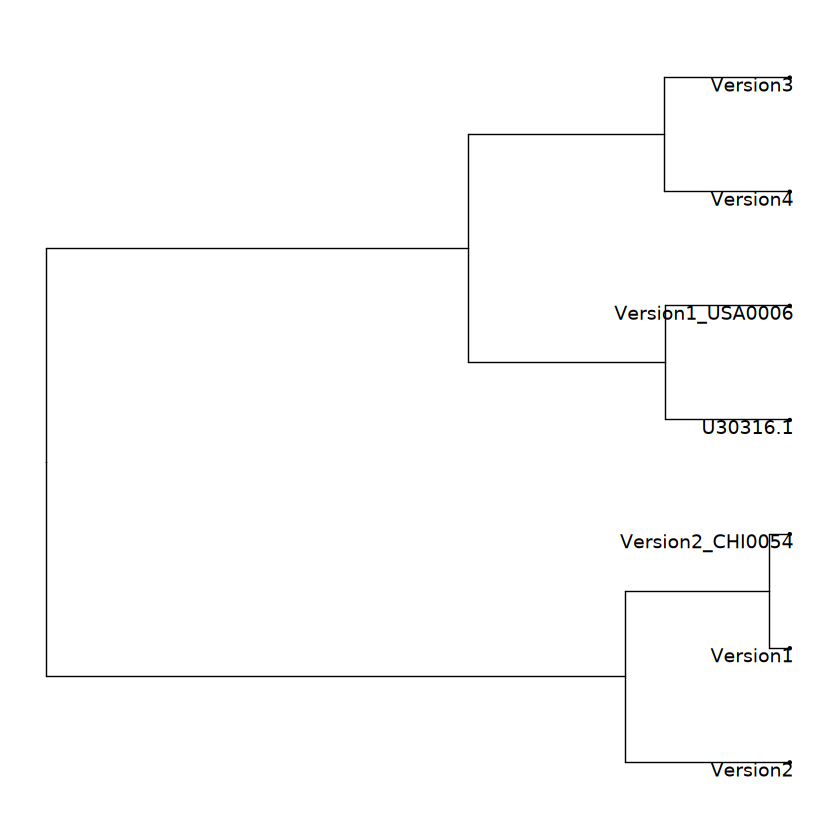

In [53]:
aligned_dnabin <- as.DNAbin(my_alignment)
dist_mat <- dist.dna(aligned_dnabin, model = "K80", pairwise.deletion = TRUE)
hc <- hclust(as.dist(dist_mat), method = "complete") 
phylo_tree <- as.phylo(hc)
options(ignore.negative.edge=TRUE)
ptrc <- ggtree(phylo_tree, size = 0.3,branch.length = 0.5) + 
  geom_tippoint(size=0.2) + geom_tiplab(hjust = 1,vjust = 1)
ptrc
ggexport(ptrc,filename = "../downstream_analysis/figures/consensus_pBI143_seq_tree_25_10_06.pdf",width = 6,height = 4)

In [169]:
#bed_data[bed_data$seq == "Version1_USA0006" & bed_data$feature == "Gap",]
#split ref fasta
point = 1830
input_sequences <- readDNAStringSet("/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/refcell/pBI143_version_ref2.fa") # 如果是DNA序列
num_sequences <- length(input_sequences)
sequence_names <- names(input_sequences)

first_half_list <- list()
second_half_list <- list()
new_names_part1 <- character(num_sequences)
new_names_part2 <- character(num_sequences)
for (i in 1:num_sequences) {
    current_sequence <- input_sequences[[i]] # 这会得到一个DNAString对象
    seq_length <- length(current_sequence)
    
    if (seq_length > 1830) {
        first_part <- subseq(current_sequence, 1, 1830)
        second_part <- subseq(current_sequence, 1831, seq_length)
    } else {
        warning(paste("Sequence", i, "(", sequence_names[i], ") is shorter than 1830 nucleotides. It will be entirely in the first part."))
        first_part <- current_sequence
        second_part <- DNAString("")
    }
    first_half_list[[i]] <- first_part
    second_half_list[[i]] <- second_part

    new_names_part1[i] <- paste0(sequence_names[i], "_part1")
    new_names_part2[i] <- paste0(sequence_names[i], "_part2")
}

first_half_set <- DNAStringSet(first_half_list)
names(first_half_set) <- new_names_part1 

second_half_set <- DNAStringSet(second_half_list)
names(second_half_set) <- new_names_part2
writeXStringSet(first_half_set, filepath = "/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/refcell/split/pBI143_version_ref2_first_half.fa")
writeXStringSet(second_half_set, filepath = "/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/refcell/split/pBI143_version_ref2_second_half.fa")

In [54]:

msa_to_bed <- function(msa_mat, ref_name = "Reference") {
  ref_row <- msa_mat[ref_name, ]
  seq_names <- setdiff(rownames(msa_mat), ref_name)
  
  bed_list <- list()
  
  for (seq_i in seq_names) {
    current_seq <- msa_mat[seq_i, ]
    current_state <- current_seq[1]
    start_pos <- 1
    bed_df_seq <- data.frame(seq = character(),
                             start = integer(),
                             end = integer(),
                             state = character(),
                             stringsAsFactors = FALSE)
    
    for (j in 2:length(current_seq)) {
      if (current_seq[j] != current_state) {
        bed_df_seq <- rbind(bed_df_seq,
                           data.frame(seq = seq_i,
                                      start = start_pos,
                                      end = j - 1,
                                      state = current_state))
        current_state <- current_seq[j]
        start_pos <- j
      }
    }
    bed_df_seq <- rbind(bed_df_seq,
                       data.frame(seq = seq_i,
                                  start = start_pos,
                                  end = length(current_seq),
                                  state = current_state))
    bed_list[[seq_i]] <- bed_df_seq
  }
  
  final_bed <- do.call(rbind, bed_list)

  final_bed$feature <- "Cover"
  final_bed$feature[final_bed$state == "-"] <- "Gap" 

  for (i in 1:nrow(final_bed)) {
    if (final_bed$state[i] != "-") {
      ref_char <- ref_row[final_bed$start[i]]
      if (final_bed$state[i] != ref_char) {
        final_bed$feature[i] <- "SNP"
      }
      if (final_bed$state[i] != ref_char & ref_char == "-") {
        final_bed$feature[i] <- "Extension"
      }
    }
  }
  
  return(final_bed)
}

bed_data <- msa_to_bed(seq_matrix,"U30316.1")
head(bed_data)

,seq,start,end,state,feature
,<chr>,<dbl>,<dbl>,<chr>,<chr>
Version4.1,Version4,1,277,-,Gap
Version4.278,Version4,278,278,G,Cover
Version4.279,Version4,279,279,A,Cover
Version4.280,Version4,280,281,T,Cover
Version4.282,Version4,282,282,G,Cover
Version4.283,Version4,283,283,T,Cover


In [55]:
qsave(bed_data,file = "pBI143_ref/cell_tree/consensus_compare.qs")

In [56]:
bed_data = qread("pBI143_ref/cell_tree/consensus_compare.qs")
bed.ref1 = bed_data[bed_data$seq %in% c("Version1_USA0006"),]
bed.ref2 = bed_data[bed_data$seq %in% c("Version2_CHI0054"),]
colnames(bed.ref1)[4] = "ref1"
colnames(bed.ref2)[4] = "ref2"
bed_data = merge(bed_data,bed.ref1[,c("start","end","ref1")],by = c("start","end"))
bed_data = merge(bed_data,bed.ref2[,c("start","end","ref2")],by = c("start","end"))
nrow(bed_data)

[1] 8922

In [57]:
bed_data$group = 3
bed_data[(bed_data$state == bed_data$ref1) & (bed_data$state == bed_data$ref2),]$group = 0
bed_data[(bed_data$state == bed_data$ref1) & (bed_data$state != bed_data$ref2),]$group = 1
bed_data[(bed_data$state != bed_data$ref1) & (bed_data$state == bed_data$ref2),]$group = 3
bed_data[(bed_data$state != bed_data$ref1) & (bed_data$state != bed_data$ref2),]$group = 2
bed_data$seq = factor(as.character(bed_data$seq),
                      levels = c('Version1_USA0006','Version2_CHI0054',
                        'Version1','Version2','Version3','Version4'))

file saved to ../downstream_analysis/figures/pBI143_version_allsnp_tile_25_10_06.pdf



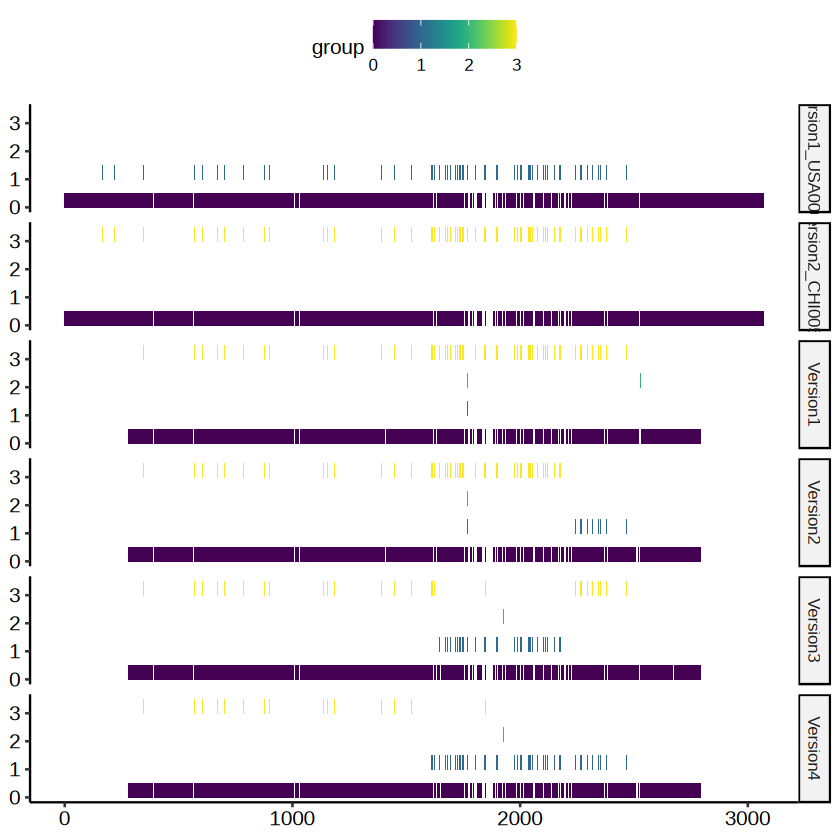

In [58]:
p1.0 = ggplot() + 
    geom_rect(data = bed_data, aes(xmin = start, xmax = end, ymin = group,ymax = group+0.5,fill = group)) + 
    facet_grid(seq~.) +
    scale_fill_viridis() +
    theme_pubr()
p1.0
ggexport(p1.0,filename = "../downstream_analysis/figures/pBI143_version_allsnp_tile_25_10_06.pdf",width = 6,height = 6)

file saved to ../downstream_analysis/figures/pBI143_version_onlysnp_point_25_10_06.pdf



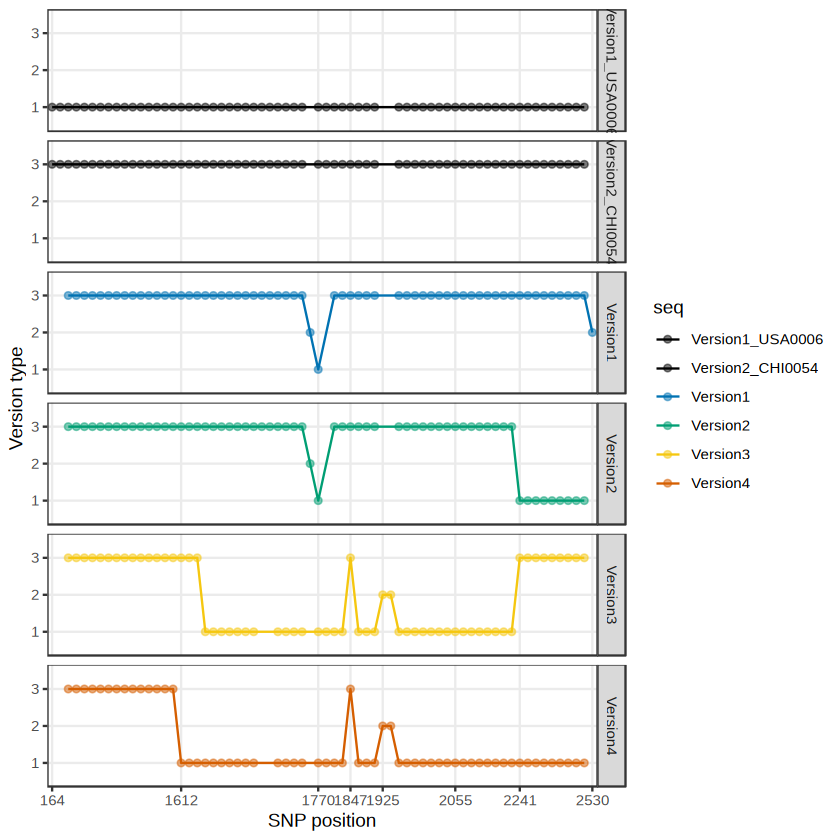

In [69]:
bed_datap = bed_data[bed_data$group != 0,]
bed_datap = bed_datap[order(bed_datap$start),]
bed_datap$order = as.factor(bed_datap$start)
#bed_datap
p1.1 = ggplot(data = bed_datap, aes(x = order,  y = group, color = seq)) + 
    geom_point(alpha = 0.5) + 
    geom_line(aes(group = seq)) +
    facet_grid(seq~.) +
    scale_color_manual(values = c("black","black","#0072B2","#009E73","#F5C710","#D55E00")) +
    theme_bw() + 
    scale_x_discrete(breaks = c(164,1612,1770,1847,1925,2055,2241,2530)) + 
    scale_y_continuous(breaks = c(0,1,2,3),limits = c(0.5,3.5)) + 
    theme(panel.grid.minor = element_blank()) + ylab("Version type") + xlab("SNP position")
p1.1
ggexport(p1.1,filename = "../downstream_analysis/figures/pBI143_version_onlysnp_point_25_10_06.pdf",width = 7,height = 5)

In [72]:
library(circlize)
bed_data <- msa_to_bed(seq_matrix,"Version1_USA0006")

#head(bed_data)
pdf("../downstream_analysis/figures/pBI143_version_compare_consensus_25_10_06.pdf",width = 6,height = 6)
ref_length <- ncol(seq_matrix) # 示例长度
#plot_seqs = unique(bed_data$seq)[order(unique(bed_data$seq))]
#plot_seqs = unique(bed_data$seq)[order(unique(bed_data$seq))]
# plot_seqs = c('Version1_USA0006','Version3','Version4',
#               'Version2_CHI0054','Version1','Version2')

plot_seqs = c('Version2_CHI0054','Version1','Version2','Version3','Version4')
#plot_seqs = c('Version1_USA0006','C282_2_lib1_out_CGAGAAGACAGTGACTTTGTCAAGTGGGA','Version2_CHI0054','C282_1_lib2_out_TCACGAAACAGGCACATAGTCATTTGCGC.fasta')

ref = "Version1_USA0006"
track = data.frame(name  = c(ref),start = c(1),end   = c(ref_length))
circos.genomicInitialize(track,major.by = 500,axis.labels.cex = 1)
feature_colors <- c("Cover" = "#009FE8", "Gap" = "white", "SNP" = "red","Extension" = "grey")
circos.par(track.height = 0.1, cell.padding = c(0, 0, 0, 0))

for (i in 1:length(plot_seqs)) {
  circos.trackPlotRegion(
    sectors = ref,
    ylim = c(0, 1),
    track.height = 0.07,
    bg.border = NA
  )
  
  current_bed <- bed_data[bed_data$seq == plot_seqs[i], ]

  for (j in 1:nrow(current_bed)) {
    circos.rect(
      xleft = current_bed$start[j],
      xright = current_bed$end[j],
      ybottom = 0,
      ytop = 1,
      sector.index = ref,
      col = feature_colors[current_bed$feature[j]],
      border = NA
    )
  }
  circos.text(
    x = mean(c(1, ref_length)),
    y = 0.5,
    sector.index = ref,
    track.index = i + 1,
    labels = plot_seqs[i],
    facing = "inside",
    niceFacing = TRUE
  )
}


legend("bottomright",
       legend = names(feature_colors),
       fill = feature_colors,
       title = "MSA Features",
       cex = 0.8)

circos.clear()
dev.off()

pdf 
  2

In [73]:
pbiref = read.delim("pBI143_ref/refmap/all_pairs_thred0_myconsensus_ref.ani")
pbiref$name = substr(pbiref$Query_file,104,nchar(pbiref$Query_file)-6)
sampledf = unique(anotdf[,c("name","sample","species","condition","group")])
pbiref = pbiref[order(pbiref$name),]
pbiref = merge(pbiref,sampledf,by = "name")
nrow(pbiref)
pbiref.fil = pbiref
#pbiref.fil = pbiref[pbiref$Align_fraction_ref > 80,]
pbiref.fil = pbiref.fil %>% group_by(name) %>% 
             filter(Align_fraction_query == max(Align_fraction_query))
pbiref.fil = pbiref.fil %>% group_by(name) %>% filter(ANI == max(ANI))
nrow(pbiref.fil)
pbiref.fil = pbiref.fil %>% group_by(name) %>% filter(n() == 1)
nrow(pbiref.fil)

[1] 21176

[1] 5425

[1] 5177

Using ANI as value column: use value.var to override.

Using Align_fraction_query as value column: use value.var to override.



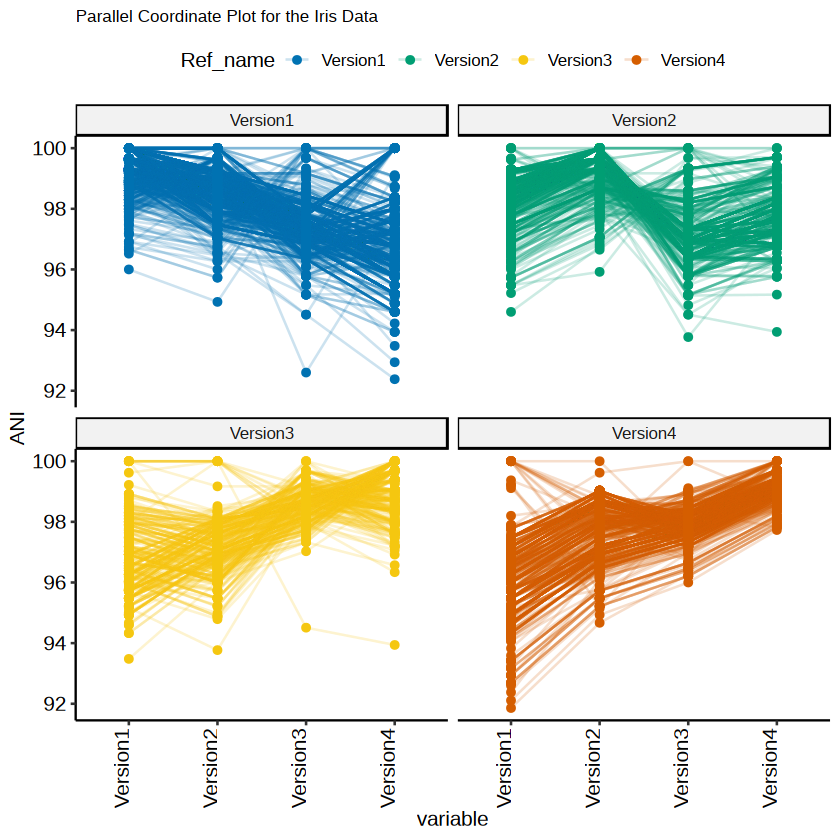

file saved to ../downstream_analysis/figures/pBI143_version_assignqc_ANI_25_10_06.pdf

file saved to ../downstream_analysis/figures/pBI143_version_assignqc_AF_25_10_06.pdf



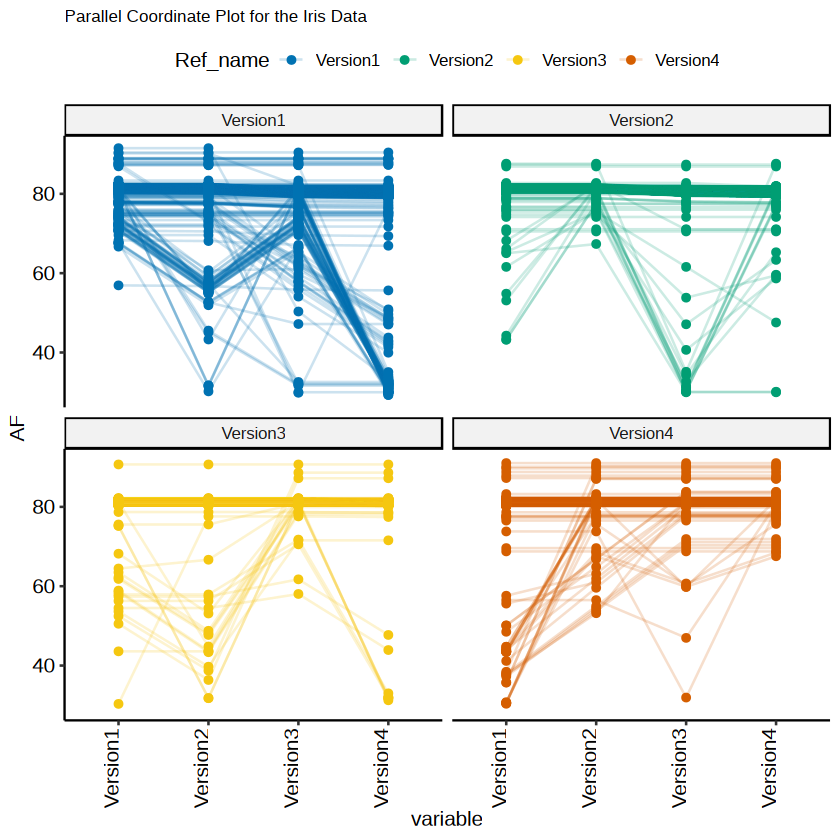

In [82]:
#library(hrbrthemes)
library(GGally)
library(viridis)
pbiref.cl = dcast(data = pbiref[,c("Ref_name","name","ANI")],name~Ref_name)
pbiref.cl = merge(pbiref.cl,pbiref.fil[,c("name","Ref_name")],by = "name")
# Plot
p1.1 = ggparcoord(pbiref.cl,
    columns = 2:5, groupColumn = 6,scale = "globalminmax",
    showPoints = TRUE, 
    title = "Parallel Coordinate Plot for the Iris Data",
    alphaLines = 0.2,
    ) + 
  scale_color_manual(values = c("#0072B2","#009E73","#F5C710","#D55E00")) +
  facet_wrap(~Ref_name) +
  theme_pubr()+
  theme(
    plot.title = element_text(size=10),axis.text.x = element_text(angle = 90, hjust = 0.5,vjust = 0)
  ) + ylab("ANI")
p1.1
pbiref.cl = dcast(data = pbiref[,c("Ref_name","name","Align_fraction_query")],name~Ref_name)
pbiref.cl = merge(pbiref.cl,pbiref.fil[,c("name","Ref_name")],by = "name")
p1.2 = ggparcoord(pbiref.cl,
    columns = 2:5, groupColumn = 6,scale = "globalminmax",
    showPoints = TRUE, 
    title = "Parallel Coordinate Plot for the Iris Data",
    alphaLines = 0.2,
    ) + 
  scale_color_manual(values = c("#0072B2","#009E73","#F5C710","#D55E00")) +
  facet_wrap(~Ref_name) +
  theme_pubr()+
  theme(
    plot.title = element_text(size=10),axis.text.x = element_text(angle = 90, hjust = 0.5,vjust = 0)
  ) + ylab("AF")
p1.2
ggexport(p1.1,filename = "../downstream_analysis/figures/pBI143_version_assignqc_ANI_25_10_06.pdf",width = 6,height = 6)
ggexport(p1.2,filename = "../downstream_analysis/figures/pBI143_version_assignqc_AF_25_10_06.pdf",width = 6,height = 6)

In [510]:
head(pbiref.fil)

name,Ref_file,Query_file,ANI,Align_fraction_ref,Align_fraction_query,Ref_name,Query_name,sample,species,condition,group
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
C282_1_lib1_out_AAACCTGACAGTCTATTGGTCAGGGCTAA,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/cell_tree/consensus_split/consunsusa_4.fasta,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/all_sample_fasta_cov_0.98/all_sample_fasta_cov_0.98/C282_1_lib1_out_AAACCTGACAGTCTATTGGTCAGGGCTAA.fasta,99.62,80.63,80.63,4_consensus,NC_005026.1,C282_1,Bacteroides thetaiotaomicron,Pretreatment,Vancomycin
C282_1_lib1_out_AAACCTGACAGTTCTCAAGTCAGAAATGA,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/cell_tree/consensus_split/consunsusa_1.fasta,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/all_sample_fasta_cov_0.98/all_sample_fasta_cov_0.98/C282_1_lib1_out_AAACCTGACAGTTCTCAAGTCAGAAATGA.fasta,99.66,81.88,82.23,1_consensus,NC_005026.1,C282_1,Bacteroides fragilis,Pretreatment,Vancomycin
C282_1_lib1_out_AACCGCGACAGAAATCCAGTCATCTTCGG,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/cell_tree/consensus_split/consunsusa_4.fasta,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/all_sample_fasta_cov_0.98/all_sample_fasta_cov_0.98/C282_1_lib1_out_AACCGCGACAGAAATCCAGTCATCTTCGG.fasta,100.00,80.55,80.64,4_consensus,NC_005026.1,C282_1,Bacteroides fragilis,Pretreatment,Vancomycin
C282_1_lib1_out_AACCGCGACAGAACTCAGGTCAGACCTGG,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/cell_tree/consensus_split/consunsusa_4.fasta,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/all_sample_fasta_cov_0.98/all_sample_fasta_cov_0.98/C282_1_lib1_out_AACCGCGACAGAACTCAGGTCAGACCTGG.fasta,98.79,81.99,82.14,4_consensus,NC_005026.1,C282_1,Bacteroides fragilis,Pretreatment,Vancomycin
C282_1_lib1_out_AACCGCGACAGACCAAGTGTCAGAACCTA,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/cell_tree/consensus_split/consunsusa_2.fasta,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/all_sample_fasta_cov_0.98/all_sample_fasta_cov_0.98/C282_1_lib1_out_AACCGCGACAGACCAAGTGTCAGAACCTA.fasta,98.84,80.39,80.39,2_consensus,NC_005026.1,C282_1,Bacteroides uniformis,Pretreatment,Vancomycin
C282_1_lib1_out_AACCGCGACAGCGTGTCTGTCAATTTCTG,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/cell_tree/consensus_split/consunsusa_1.fasta,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/all_sample_fasta_cov_0.98/all_sample_fasta_cov_0.98/C282_1_lib1_out_AACCGCGACAGCGTGTCTGTCAATTTCTG.fasta,100.00,82.13,82.13,1_consensus,NC_005026.1,C282_1,Bacteroides thetaiotaomicron,Pretreatment,Vancomycin


In [84]:
write.csv(pbiref.fil,file = "pBI143_version_group_my_25_10_06.txt",quote = F, row.names = F)

file saved to ../downstream_analysis/figures/pBI143_myversion_maxANI_box_25_10_06.pdf



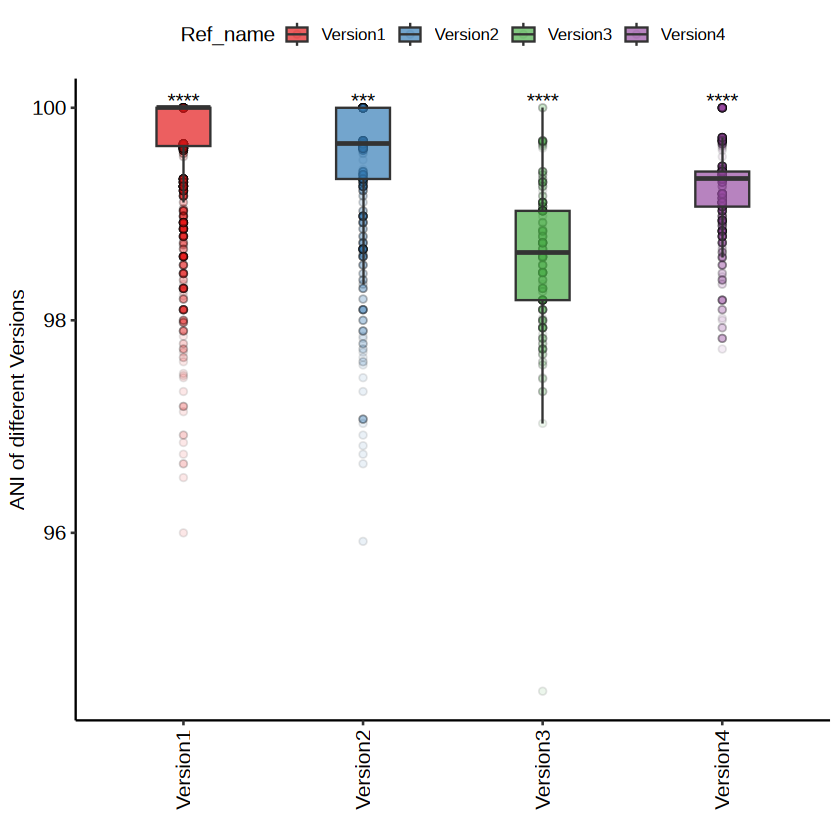

In [85]:
p1.3 = ggplot(pbiref.fil,
              aes(x = Ref_name,y = ANI,fill = Ref_name)) + 
    geom_point(size = 1.5,shape = 21,alpha = 0.1) +    
    geom_boxplot(width = 0.3,lwd = 0.5,outlier.shape = NA,alpha = .7) +
    #geom_line(aes(group = group,color = group),lwd = 0.5,alpha = 0.5,linetype = 2,position = position_dodge(0.1)) +
    scale_fill_brewer(palette = "Set1") +
    stat_compare_means(method = "t.test",ref.group = ".all.",hide.ns = T,label = "p.signif") + 
    theme_pubr() + 
    xlab("") + ylab("ANI of different Versions") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p1.3
ggexport(p1.3,filename = "../downstream_analysis/figures/pBI143_myversion_maxANI_box_25_10_06.pdf",width = 6,height = 5)


Attaching package: 'tidyplots'


The following object is masked from 'package:phangorn':

    add_boxplot


The following object is masked from 'package:ggpubr':

    gene_expression


file saved to ../downstream_analysis/figures/pBI143_myversion_stat_25_10_06.pdf



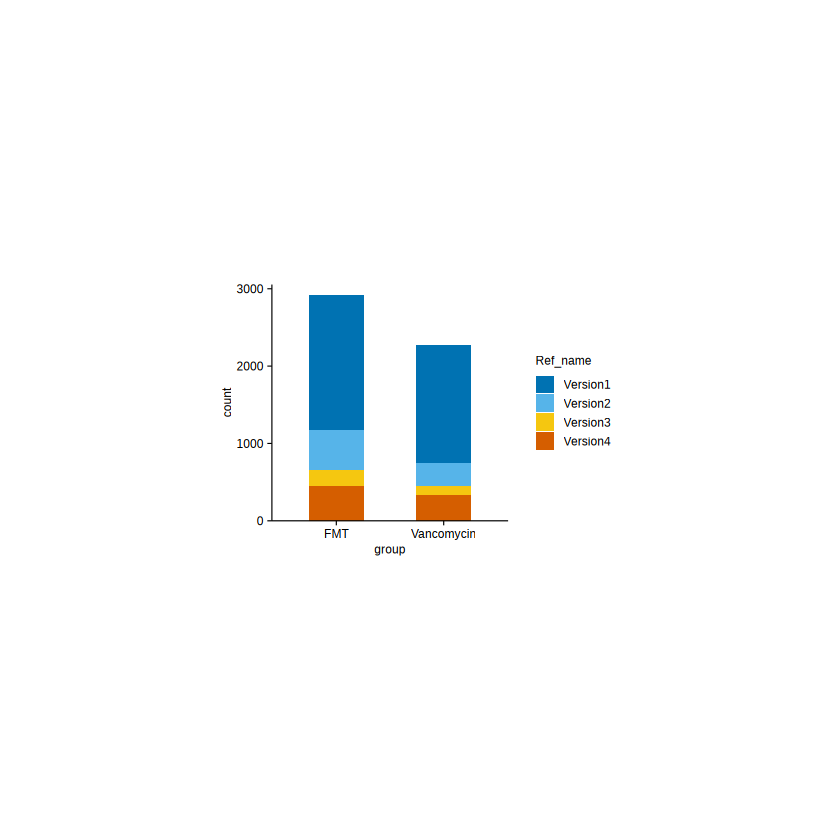

In [86]:
library(tidyplots)
p1 = pbiref.fil |>
  tidyplot(x = group, color = Ref_name) |>
  add_barstack_absolute(width = 0.5)
p1
ggexport(p1,filename = "../downstream_analysis/figures/pBI143_myversion_stat_25_10_06.pdf",width = 5,height = 4)

✔ split_plot: split into 2 plots across 1 page

file saved to ../downstream_analysis/figures/pBI143_myversion_species_stat_25_10_06.pdf



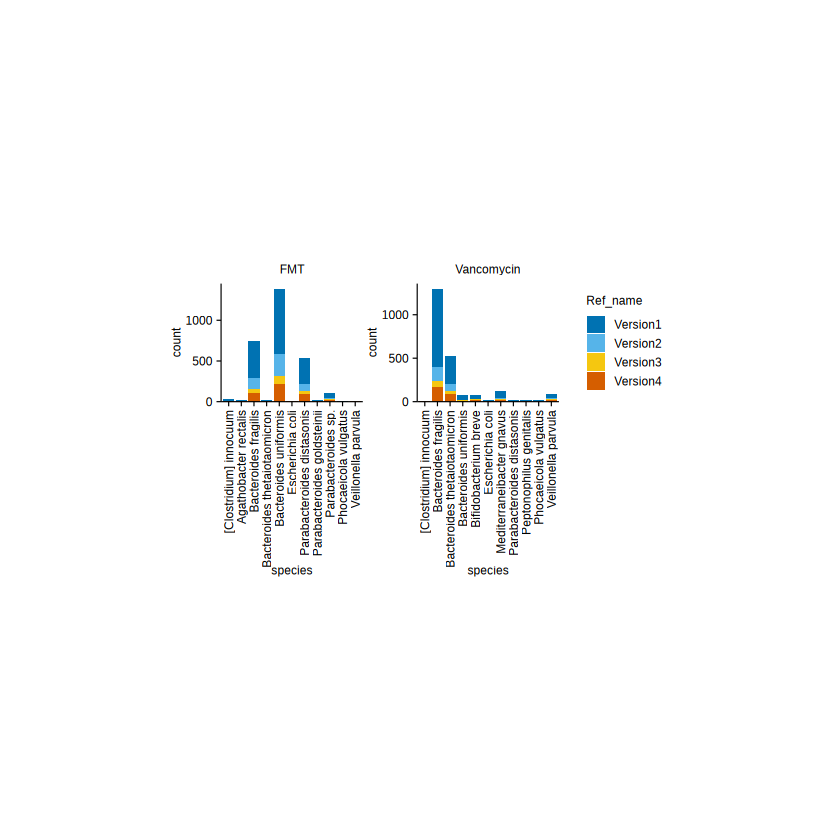

In [87]:
pbiref.sp = pbiref.fil %>% group_by(species) %>% filter(length(unique(name)) > 10)
p1.1 = pbiref.sp |>
  tidyplot(x = species, color = Ref_name) |>
  add_barstack_absolute() |> adjust_x_axis(rotate_labels = 90) |> split_plot(by = group)
p1.1
ggexport(p1.1,filename = "../downstream_analysis/figures/pBI143_myversion_species_stat_25_10_06.pdf",width = 7,height = 4)

In [170]:
#try split ref
pbiref = read.delim("pBI143_ref/refmap/all_pairs_splitref_thred0.ani")
pbiref$name = substr(pbiref$Query_file,104,nchar(pbiref$Query_file)-6)
sampledf = unique(anotdf[,c("name","sample","species","condition","group")])
pbiref = pbiref[order(pbiref$name),]
pbiref = merge(pbiref,sampledf,by = "name")
head(pbiref)
# nrow(pbiref)
# pbiref.fil = pbiref[pbiref$Align_fraction_ref > 80,]
# nrow(pbiref.fil)
# pbiref.fil = pbiref.fil %>% group_by(name) %>% filter(ANI == max(ANI))
# nrow(pbiref.fil)


,name,Ref_file,Query_file,ANI,Align_fraction_ref,Align_fraction_query,Ref_name,Query_name,sample,species,condition,group
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,C282_1_lib1_out_AAACCTGACAGTCTATTGGTCAGGGCTAA,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/refcell/split/pBI143_version_ref1_first_half.fa,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/all_sample_fasta_cov_0.98/all_sample_fasta_cov_0.98/C282_1_lib1_out_AAACCTGACAGTCTATTGGTCAGGGCTAA.fasta,98.79,45.63,30.01,Version1_USA0006_part1,NC_005026.1,C282_1,Bacteroides thetaiotaomicron,Pretreatment,Vancomycin
2,C282_1_lib1_out_AAACCTGACAGTCTATTGGTCAGGGCTAA,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/refcell/split/pBI143_version_ref2_second_half.fa,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/all_sample_fasta_cov_0.98/all_sample_fasta_cov_0.98/C282_1_lib1_out_AAACCTGACAGTCTATTGGTCAGGGCTAA.fasta,98.98,100.00,39.50,Version2_CHI0054_part2,NC_005026.1,C282_1,Bacteroides thetaiotaomicron,Pretreatment,Vancomycin
3,C282_1_lib1_out_AAACCTGACAGTCTATTGGTCAGGGCTAA,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/refcell/split/pBI143_version_ref2_first_half.fa,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/all_sample_fasta_cov_0.98/all_sample_fasta_cov_0.98/C282_1_lib1_out_AAACCTGACAGTCTATTGGTCAGGGCTAA.fasta,100.00,64.97,42.74,Version2_CHI0054_part1,NC_005026.1,C282_1,Bacteroides thetaiotaomicron,Pretreatment,Vancomycin
4,C282_1_lib1_out_AAACCTGACAGTTCTCAAGTCAGAAATGA,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/refcell/split/pBI143_version_ref1_first_half.fa,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/all_sample_fasta_cov_0.98/all_sample_fasta_cov_0.98/C282_1_lib1_out_AAACCTGACAGTTCTCAAGTCAGAAATGA.fasta,98.79,45.63,30.04,Version1_USA0006_part1,NC_005026.1,C282_1,Bacteroides fragilis,Pretreatment,Vancomycin
5,C282_1_lib1_out_AAACCTGACAGTTCTCAAGTCAGAAATGA,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/refcell/split/pBI143_version_ref2_first_half.fa,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/all_sample_fasta_cov_0.98/all_sample_fasta_cov_0.98/C282_1_lib1_out_AAACCTGACAGTTCTCAAGTCAGAAATGA.fasta,100.00,64.97,42.77,Version2_CHI0054_part1,NC_005026.1,C282_1,Bacteroides fragilis,Pretreatment,Vancomycin
6,C282_1_lib1_out_AAACCTGACAGTTCTCAAGTCAGAAATGA,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/refcell/split/pBI143_version_ref2_second_half.fa,/cluster/home/liuhengxin/P_CAP-seq/data/pBI143_ref/all_sample_fasta_cov_0.98/all_sample_fasta_cov_0.98/C282_1_lib1_out_AAACCTGACAGTTCTCAAGTCAGAAATGA.fasta,100.00,100.00,41.01,Version2_CHI0054_part2,NC_005026.1,C282_1,Bacteroides fragilis,Pretreatment,Vancomycin


[1] 15888

[1] 11226

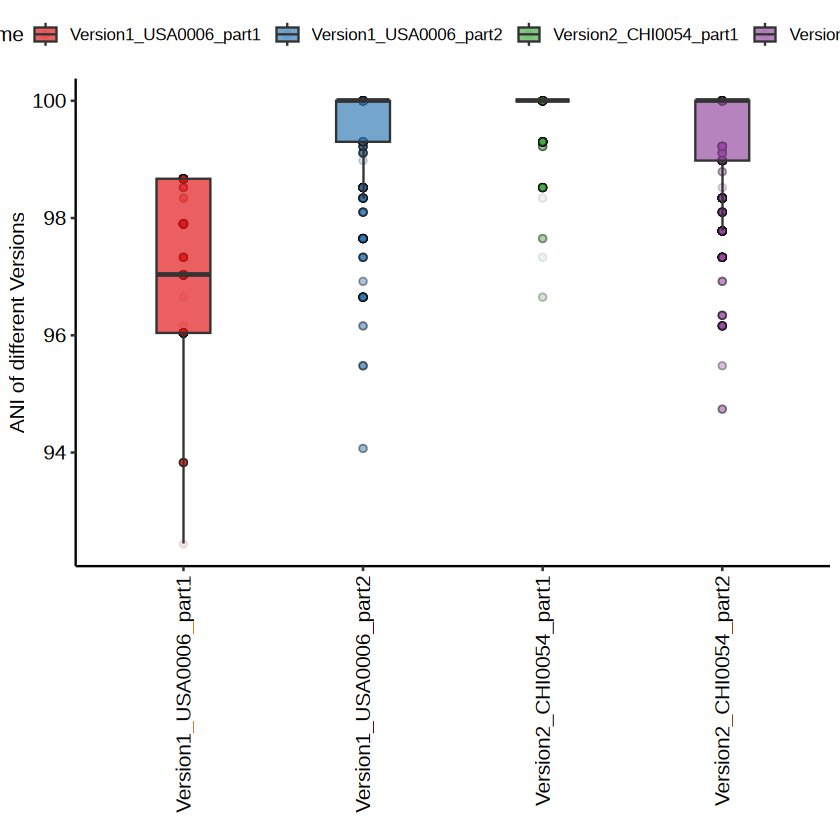

In [178]:
nrow(pbiref)
pbiref.hub = pbiref[pbiref$Align_fraction_ref > 60,]
nrow(pbiref.hub)
p1.3 = ggplot(pbiref.hub,
              aes(x = Ref_name,y = ANI,fill = Ref_name)) + 
    geom_point(size = 1.5,shape = 21,alpha = 0.1) +    
    geom_boxplot(width = 0.3,lwd = 0.5,outlier.shape = NA,alpha = .7) +
    #geom_line(aes(group = group,color = group),lwd = 0.5,alpha = 0.5,linetype = 2,position = position_dodge(0.1)) +
    scale_fill_brewer(palette = "Set1") +
    #stat_compare_means(method = "t.test") + 
    theme_pubr() + 
    xlab("") + ylab("ANI of different Versions") +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5))
p1.3

Using ANI as value column: use value.var to override.

Warning message:
"Removed 5073 rows containing missing values or values outside the scale range
(`geom_point()`)."
Warning message:
"Removed 5145 rows containing missing values or values outside the scale range
(`geom_point()`)."


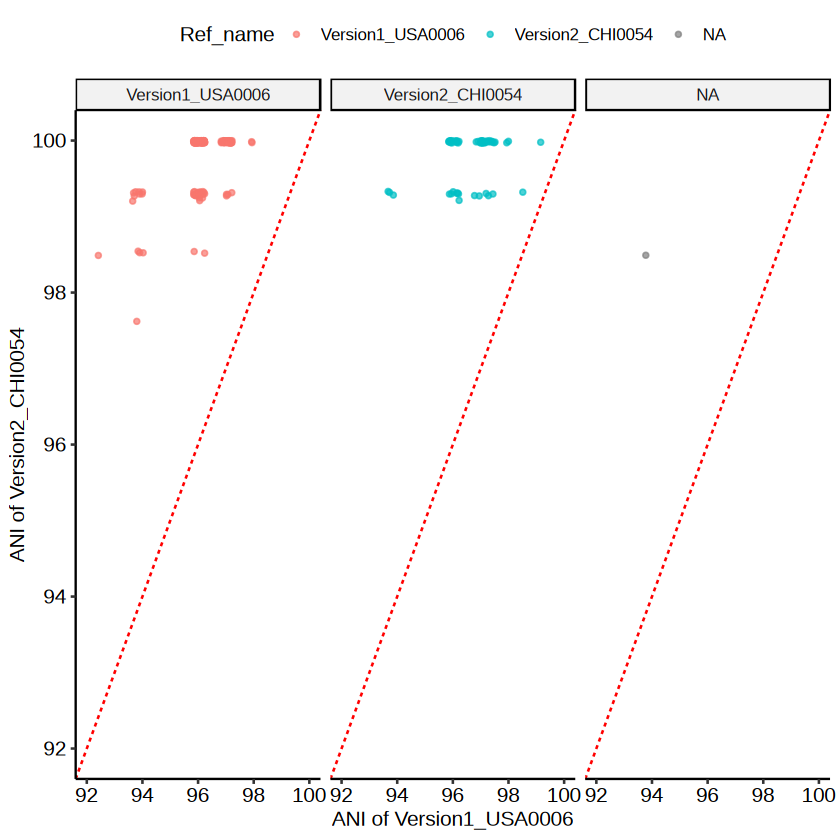

Warning message:
"Removed 5090 rows containing missing values or values outside the scale range
(`geom_point()`)."
file saved to ../downstream_analysis/figures/pBI143_refversion_ANI_compare_point_part1_25_09_11.pdf

Warning message:
"Removed 5144 rows containing missing values or values outside the scale range
(`geom_point()`)."
file saved to ../downstream_analysis/figures/pBI143_refversion_ANI_compare_point_part2_25_09_11.pdf



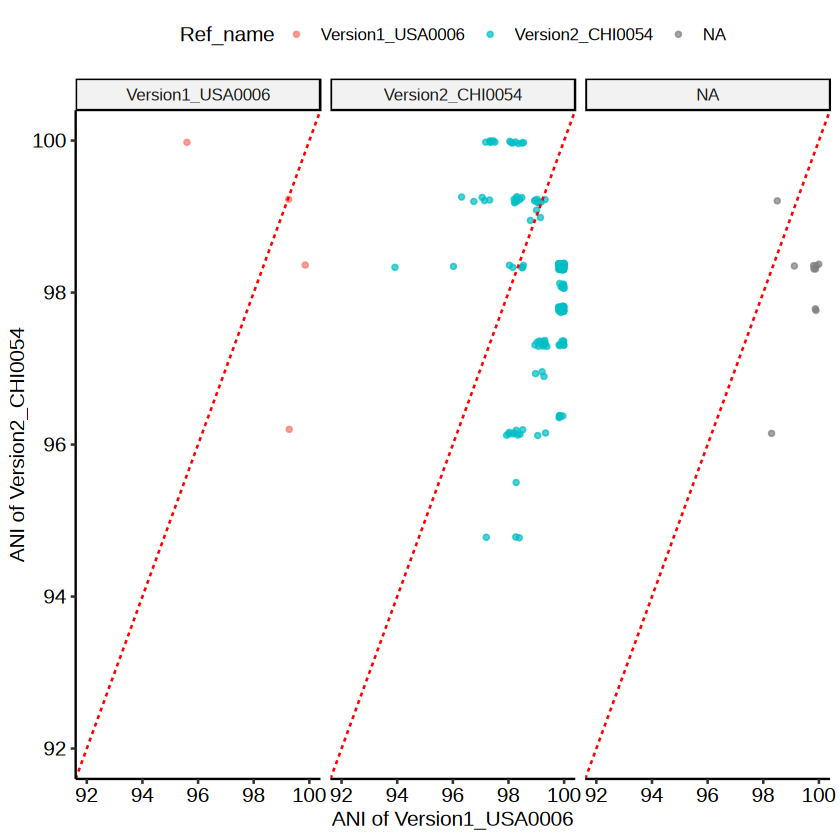

In [195]:
#pbiref.hub = pbiref.hub %>% group_by(name) %>% filter(n() > 1)
pbiref.hub = pbiref[pbiref$Align_fraction_ref > 50,]
pbiref.cl = dcast(data = pbiref.hub[,c("Ref_name","name","ANI")],name~Ref_name)
pbiref.cl = merge(pbiref.cl,pbiref.fil[,c("name","Ref_name")],by = "name",all = TRUE)
#head(pbiref.cl)
#pbiref.cl = merge(pbiref.cl,pbiref.fil[,c("name","Ref_name")],by = "name",all = TRUE)
#ggplot(pbiref.cl,aes(x = Version1_USA0006,y = Version2_CHI0054))
p1.2 = ggplot(pbiref.cl,
              aes(x = Version1_USA0006_part1,y = Version2_CHI0054_part1,color = Ref_name)) + 
   # geom_smooth(method="lm", col="black",se = FALSE,alpha = 0.5) + 
    geom_jitter(size = 1,alpha = 0.7,width = 0.2) +
    geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed") +
    facet_wrap(~Ref_name) +
    #stat_cor(method = "pearson", label.x = 0.3, label.y = 0.7) +
    scale_fill_discreterainbow() +
    scale_x_continuous(limits = c(92,100)) + scale_y_continuous(limits = c(92,100)) + 
    xlab("ANI of Version1_USA0006") + ylab("ANI of Version2_CHI0054") +
    theme_pubr()
p1.2
p1.3 = ggplot(pbiref.cl,
              aes(x = Version1_USA0006_part2,y = Version2_CHI0054_part2,color = Ref_name)) + 
   # geom_smooth(method="lm", col="black",se = FALSE,alpha = 0.5) + 
    geom_jitter(size = 1,alpha = 0.7,width = 0.2) +
    geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed") +
    facet_wrap(~Ref_name) +
    #stat_cor(method = "pearson", label.x = 0.3, label.y = 0.7) +
    scale_fill_discreterainbow() +
    scale_x_continuous(limits = c(92,100)) + scale_y_continuous(limits = c(92,100)) + 
    xlab("ANI of Version1_USA0006") + ylab("ANI of Version2_CHI0054") +
    theme_pubr()
p1.3
ggexport(p1.2,filename = "../downstream_analysis/figures/pBI143_refversion_ANI_compare_point_part1_25_09_11.pdf",width = 6,height = 4)
ggexport(p1.3,filename = "../downstream_analysis/figures/pBI143_refversion_ANI_compare_point_part2_25_09_11.pdf",width = 6,height = 4)

`summarise()` has grouped output by 'group'. You can override using the
`.groups` argument.
file saved to ../downstream_analysis/figures/f3.0_pBI143_version_stat_total_25_09_12.pdf



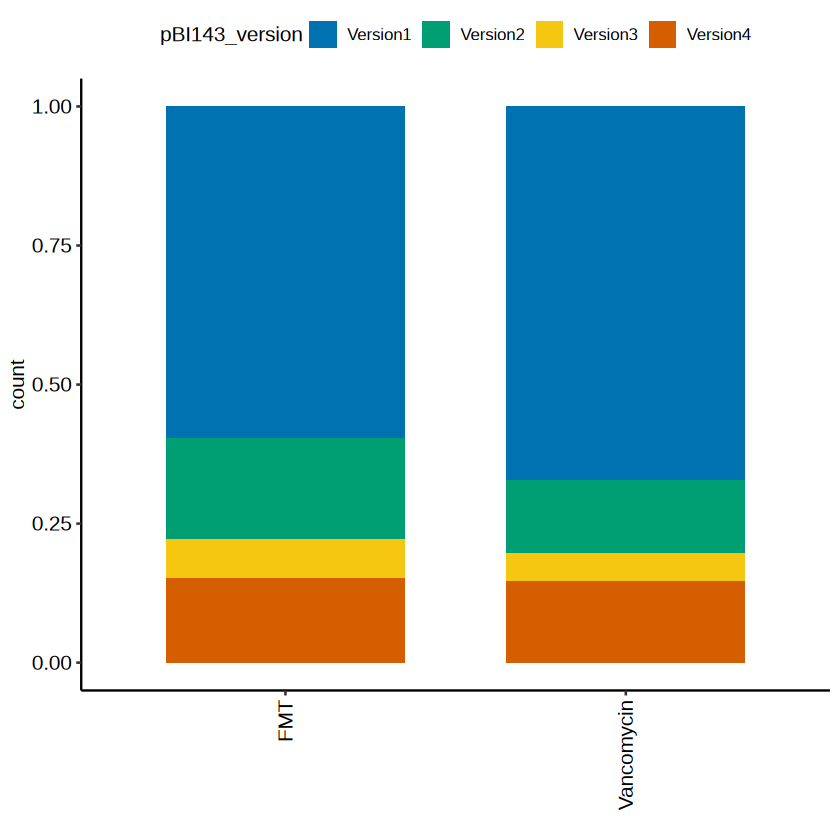

In [94]:
# pbidfv$group = MySplit(pbidfv$new_name,"_",1)
# pbidfv$condition = MySplit(pbidfv$new_name,"_",2)
# pbidfv[pbidfv$group == "C282",]$group = "Vancomycin"
# pbidfv[pbidfv$group == "C295",]$group = "FMT"
# pbidfv[pbidfv$condition == "1",]$condition = "Pretreatment"
# pbidfv[pbidfv$condition == "2",]$condition = "Ontreatment"
# pbidfv[pbidfv$condition == "3",]$condition = "Posttreatment"
pbidfv.st1 = pbidfv %>% group_by(group,pBI143_version) %>% dplyr::summarise(count = length(unique(name)))
#pbidfv.st1
pbidfv.st1$pBI143_version = as.character(pbidfv.st1$pBI143_version)
p3.0 = ggplot(pbidfv.st1,aes(x = group,y = count,fill = pBI143_version)) +
    geom_bar(stat = "identity",position = "fill",width = 0.7) +
    #facet_grid(~group) +
    scale_fill_manual(values = c("#0072B2","#009E73","#F5C710","#D55E00")) +
    theme_pubr() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5)) + xlab("")
p3.0
ggexport(p3.0, 
         filename = "../downstream_analysis/figures/f3.0_pBI143_version_stat_total_25_09_12.pdf",
         width = 2,height = 4)

`summarise()` has grouped output by 'group', 'condition'. You can override
using the `.groups` argument.
file saved to ../downstream_analysis/figures/f3.1_pBI143_version_stat_25_09_14.pdf



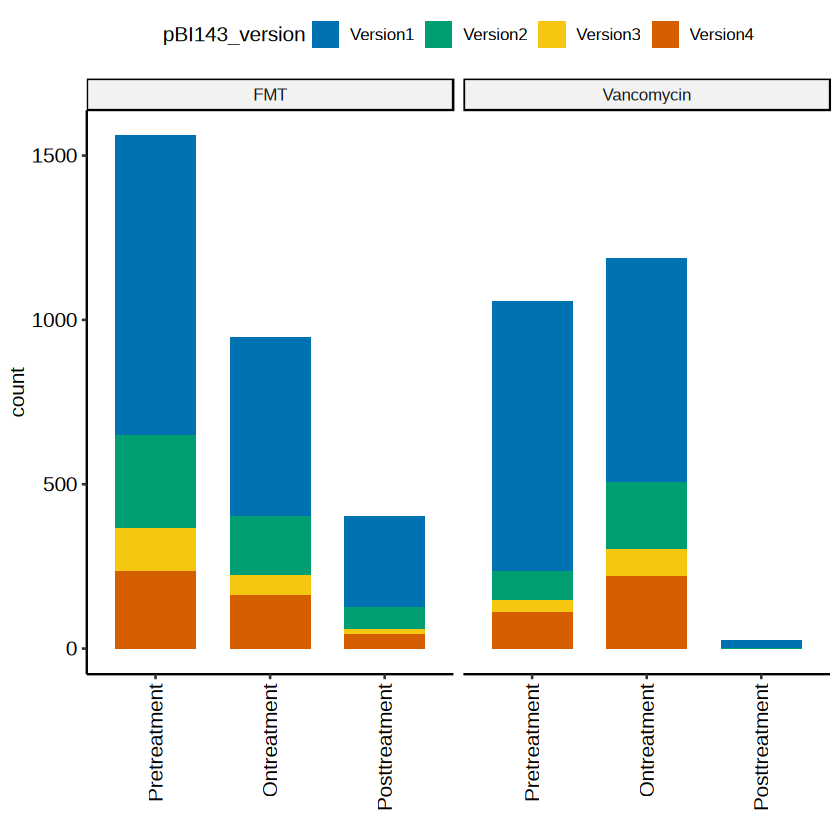

In [95]:
pbidfv.st1 = pbidfv %>% group_by(group,condition,pBI143_version) %>% dplyr::summarise(count = length(unique(name)))
pbidfv.st1$condition = factor(pbidfv.st1$condition,levels = c("Pretreatment","Ontreatment","Posttreatment"))

pbidfv.st1$pBI143_version = as.character(pbidfv.st1$pBI143_version)
p3.1 = ggplot(pbidfv.st1,aes(x = condition,y = count,fill = pBI143_version)) +
    geom_bar(stat = "identity",position = "stack",width = 0.7) +
    facet_grid(~group) +
    scale_fill_manual(values = c("#0072B2","#009E73","#F5C710","#D55E00")) +
    theme_pubr() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5)) + xlab("")
p3.1
#p3.1
ggexport(p3.1, 
         filename = "../downstream_analysis/figures/f3.1_pBI143_version_stat_25_09_14.pdf",
         width = 3,height = 4)

file saved to ../downstream_analysis/figures/f3.1_pBI143_version_fill_stat_25_09_14.pdf



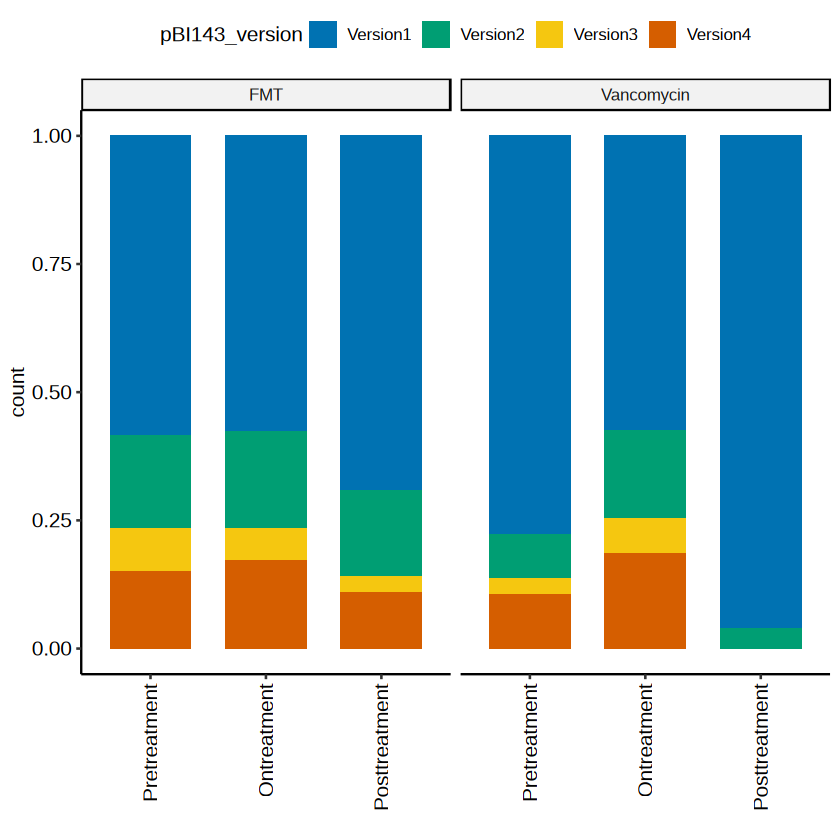

In [96]:
p3.1 = ggplot(pbidfv.st1,aes(x = condition,y = count,fill = pBI143_version)) +
    geom_bar(stat = "identity",position = "fill",width = 0.7) +
    facet_grid(~group) +
    scale_fill_manual(values = c("#0072B2","#009E73","#F5C710","#D55E00")) +
    theme_pubr() +
    theme(axis.text.x = element_text(angle = 90, hjust = 1,vjust = 0.5)) + xlab("")
p3.1
#p3.1
ggexport(p3.1, 
         filename = "../downstream_analysis/figures/f3.1_pBI143_version_fill_stat_25_09_14.pdf",
         width = 3,height = 4)

Warning message:
"package 'ggalluvial' was built under R version 4.3.3"
`summarise()` has grouped output by 'pBI143_version'. You can override using
the `.groups` argument.


[1] 11

file saved to ../downstream_analysis/figures/f3.1_pBI143_version_sankey_25_09_14.pdf



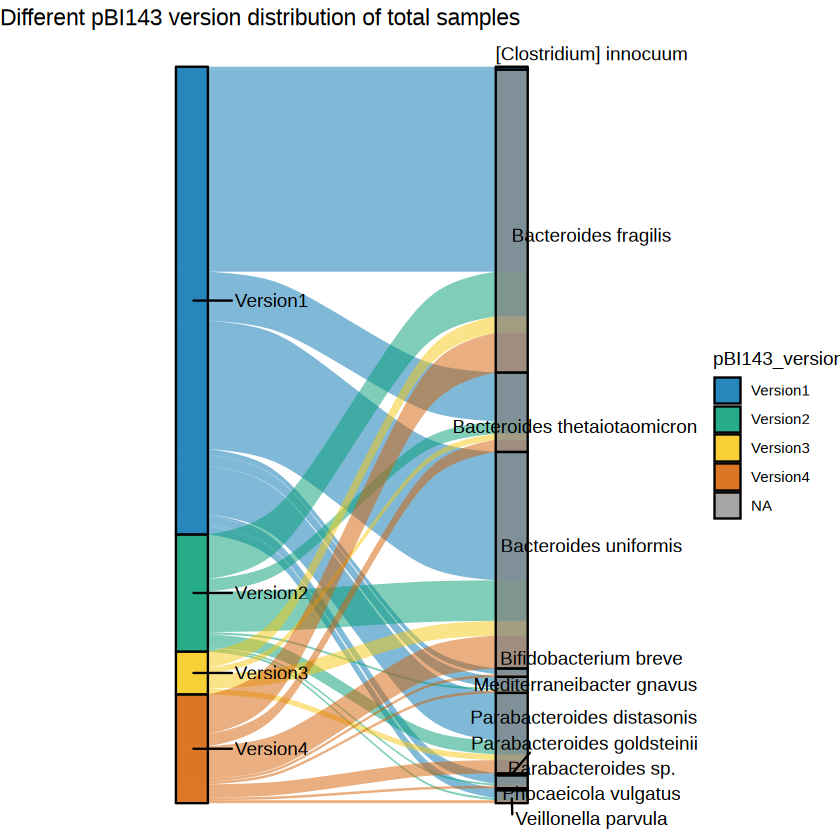

In [97]:
library(ggalluvial)
library(ggrepel)
pbidf.st = pbidfv %>% group_by(pBI143_version,species) %>% dplyr::summarise(cellnum = n())
pbidf.st = pbidf.st[pbidf.st$cellnum > 10,]
length(unique(pbidf.st$species))
#pbidf.st
#pbidf.st$pBI143_version = paste0("pBI143\n","Version",pbidf.st$pBI143_version)
pbidf.st$pBI143_version = as.character(pbidf.st$pBI143_version)
p3.2.0 = ggplot(data = pbidf.st,
       aes(axis1 = pBI143_version, axis2 = species, 
           y = cellnum)) +
  scale_x_discrete(limits = c("pBI143_version", "species")) +
  xlab("Demographic") +
  geom_alluvium(aes(fill = pBI143_version),width = 0.1) +
  geom_stratum(aes(fill = pBI143_version),width = 0.1,alpha = 0.7) +
  geom_text_repel(stat = "stratum", aes(label = after_stat(stratum)),
                  force  = 0.5, direction = "y",
                   nudge_x = 0.25, segment.size = 0.5) +
  scale_fill_manual(values = c("#0072B2","#009E73","#F5C710","#D55E00")) +
  theme_void() +
  ggtitle("Different pBI143 version distribution of total samples")
p3.2.0
ggexport(p3.2.0, 
         filename = "../downstream_analysis/figures/f3.1_pBI143_version_sankey_25_10_06.pdf",
         width = 8,height = 6.5)

`summarise()` has grouped output by 'pBI143_version'. You can override using
the `.groups` argument.


[1] 10

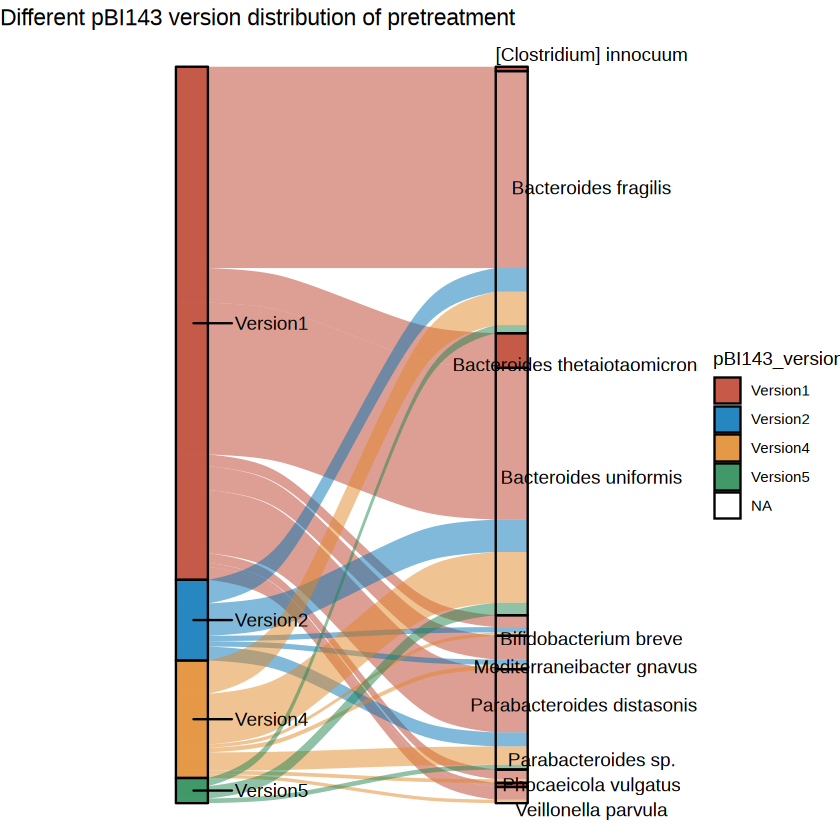

In [521]:
pbidf.st = pbidfv[pbidfv$condition == "Pretreatment",] %>% group_by(pBI143_version,species) %>% dplyr::summarise(cellnum = n())
pbidf.st = pbidf.st[pbidf.st$cellnum > 10,]
length(unique(pbidf.st$species))
#pbidf.st$pBI143_version = pbidf.st$pBI143_version
library(ggalluvial)
library(ggrepel)
pbidf.st$pBI143_version = as.character(pbidf.st$pBI143_version)
p3.2.1 = ggplot(data = pbidf.st,
       aes(axis1 = pBI143_version, axis2 = species, 
           y = cellnum)) +
  scale_x_discrete(limits = c("pBI143_version", "species")) +
  xlab("Demographic") +
  geom_alluvium(aes(fill = pBI143_version),width = 0.1) +
  geom_stratum(aes(fill = pBI143_version),width = 0.1,alpha = 0.7) +
  geom_text_repel(stat = "stratum", aes(label = after_stat(stratum)),
                  force  = 0.5, direction = "y",
                   nudge_x = 0.25, segment.size = 0.5) +
  scale_fill_nejm()+
  theme_void() +
  ggtitle("Different pBI143 version distribution of pretreatment")
p3.2.1

`summarise()` has grouped output by 'pBI143_version'. You can override using
the `.groups` argument.


[1] 7

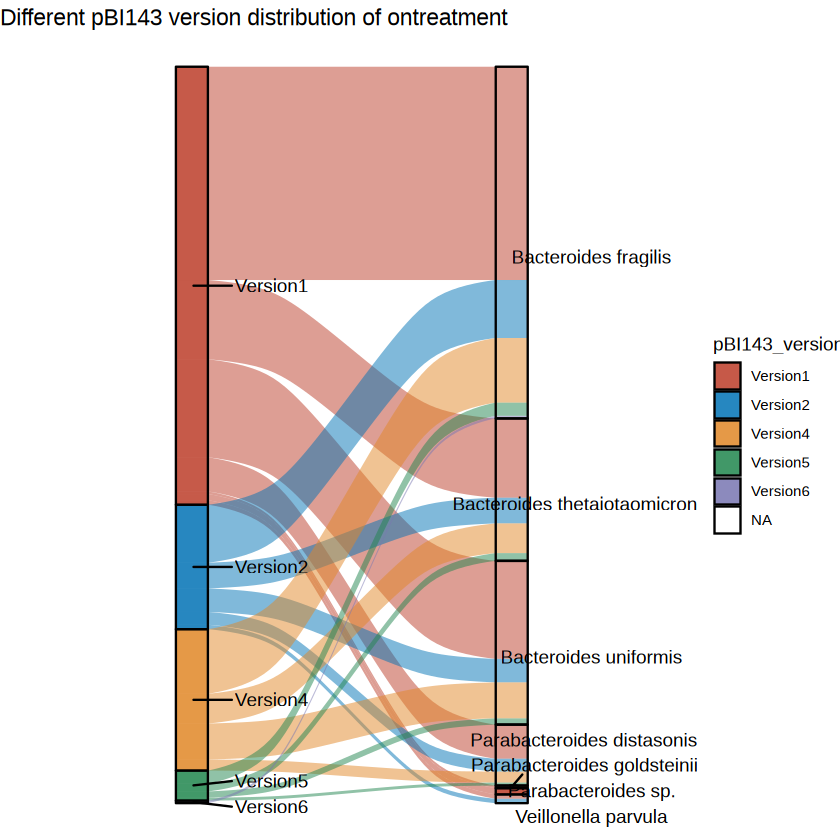

In [522]:
pbidf.st = pbidfv[pbidfv$condition == "Ontreatment",] %>% group_by(pBI143_version,species) %>% dplyr::summarise(cellnum = n())
pbidf.st = pbidf.st[pbidf.st$cellnum > 5,]
length(unique(pbidf.st$species))
#pbidf.st$pBI143_version = paste0("pBI143\n","Version",pbidf.st$pBI143_version)
library(ggalluvial)
library(ggrepel)
pbidf.st$pBI143_version = as.character(pbidf.st$pBI143_version)
p3.2.2 = ggplot(data = pbidf.st,
       aes(axis1 = pBI143_version, axis2 = species, 
           y = cellnum)) +
  scale_x_discrete(limits = c("pBI143_version", "species")) +
  xlab("Demographic") +
  geom_alluvium(aes(fill = pBI143_version),width = 0.1) +
  geom_stratum(aes(fill = pBI143_version),width = 0.1,alpha = 0.7) +
  geom_text_repel(stat = "stratum", aes(label = after_stat(stratum)),
                  force  = 0.5, direction = "y",
                   nudge_x = 0.25, segment.size = 0.5) +
  scale_fill_nejm()+
  theme_void() +
  ggtitle("Different pBI143 version distribution of ontreatment")
p3.2.2

`summarise()` has grouped output by 'pBI143_version'. You can override using
the `.groups` argument.


[1] 4

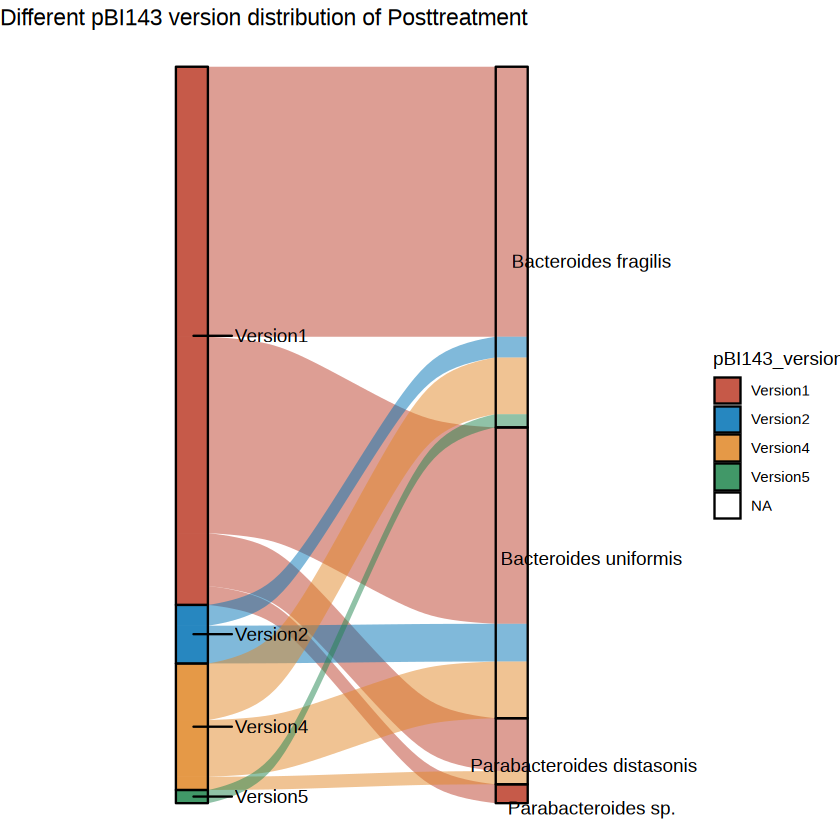

In [523]:
pbidf.st = pbidfv[pbidfv$condition == "Posttreatment",] %>% group_by(pBI143_version,species) %>% dplyr::summarise(cellnum = n())
pbidf.st = pbidf.st[pbidf.st$cellnum > 5,]
length(unique(pbidf.st$species))
#pbidf.st$pBI143_version = paste0("pBI143\n","Version",pbidf.st$pBI143_version)
library(ggalluvial)
library(ggrepel)
pbidf.st$pBI143_version = as.character(pbidf.st$pBI143_version)
p3.2.3 = ggplot(data = pbidf.st,
       aes(axis1 = pBI143_version, axis2 = species, 
           y = cellnum)) +
  scale_x_discrete(limits = c("pBI143_version", "species")) +
  xlab("Demographic") +
  geom_alluvium(aes(fill = pBI143_version),width = 0.1) +
  geom_stratum(aes(fill = pBI143_version),width = 0.1,alpha = 0.7) +
  geom_text_repel(stat = "stratum", aes(label = after_stat(stratum)),
                  force  = 0.5, direction = "y",
                   nudge_x = 0.25, segment.size = 0.5) +
  scale_fill_nejm()+
  theme_void() +
  ggtitle("Different pBI143 version distribution of Posttreatment")
p3.2.3

file saved to ../downstream_analysis/figures/f3.1_pBI143_version_sankey_samples_25_09_14.pdf



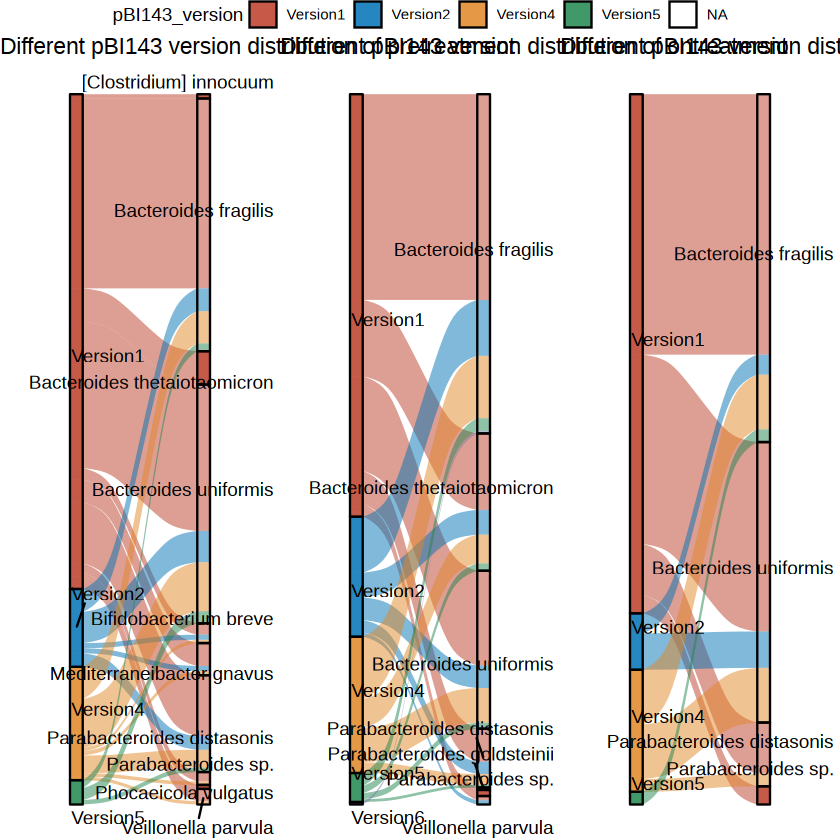

In [524]:
p3t = ggarrange(p3.2.1,p3.2.2,p3.2.3,nrow = 1,common.legend = T)
p3t
ggexport(p3t, 
         filename = "../downstream_analysis/figures/f3.1_pBI143_version_sankey_samples_25_09_14.pdf",
         width = 10,height = 4)